# Preprocessing Pipeline


This notebook takes raw stellar brightness measurements from NASA's Kepler space telescope and transforms them into a clean, labeled dataset of fixed-length time-series windows, ready to used for training of CNN Models.<br><br>


Input: ~9,500 stars from the Kepler KOI catalog, each labeled as a confirmed planet host or false positive; their raw 4-year brightness time series downloaded from NASA's MAST archive.


Output: A folder of .npz files, each containing a 201-cadence window (≈ 4 days of starlight) paired with a binary label (1 = transit present, 0 = not). These are your training examples.
<br><br>


The six stages covered here:


**Environment Setup** — install packages, mount Drive, define all paths and hyperparameters in one place.


**Catalog Ingestion** — download the KOI label table from NASA and engineer your binary training labels.


**Light Curve Ingestion** (sample) — download a representative sample of light curves for EDA.


**Data Validation & EDA** — visualize the raw data to understand signal properties, class imbalance, stellar noise structure, and gaps. This directly informs every architectural decision in the next notebook.


**Detrending & normalization using Whittaker-Henderson smoothing**


**Sliding-window segmentation, augmentation, and train/val/test split**

## Environment Setup

In [2]:
# Install Dependencies
# Run once per Colab session. The -q flag suppresses verbose output.
!pip install -q "fsspec==2025.3.0" lightkurve astropy astroquery batman-package

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 3.8 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ── 1. Imports
import json
import logging
import time
import warnings
from datetime import datetime
from io import StringIO
from pathlib import Path
from tqdm.notebook import tqdm

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

import lightkurve as lk
from astropy.timeseries import LombScargle
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

warnings.filterwarnings('ignore')

# ── 3. Path Configuration (edit BASE_DIR if your Drive layout differs) ─────────
BASE_DIR        = Path('/content/drive/MyDrive/PROJECT_ROOT')
DATA_DIR        = BASE_DIR  / 'data'
RAW_LC_DIR      = DATA_DIR  / 'raw'      / 'light_curves'   # downloaded .npz per star
RAW_CAT_DIR     = DATA_DIR  / 'raw'      / 'catalogs'       # KOI CSV
PROCESSED_DIR   = DATA_DIR  / 'processed'                   # detrended light curves
WINDOWS_DIR     = DATA_DIR  / 'windows'                     # final windowed dataset
WINDOWS_PLUS_DIR= DATA_DIR  / 'windows_plus'                # augmented windowed dataset
FIGURES_DIR     = BASE_DIR  / 'figures'
MODELS_DIR      = BASE_DIR  / 'models'
LOGS_DIR        = BASE_DIR  / 'logs'
CHECKPOINTS_DIR = BASE_DIR  / 'checkpoints'

for d in [RAW_LC_DIR, RAW_CAT_DIR, PROCESSED_DIR, WINDOWS_DIR,WINDOWS_PLUS_DIR,
          FIGURES_DIR, MODELS_DIR, LOGS_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── 4. Hyperparameters & Config ────────────────────────────────────────────────
CONFIG = {
    # --- Data ---
    'random_seed'         : 42,
    'kepler_cadence_min'  : 29.4,       # minutes per long-cadence observation

    # --- Preprocessing ---
    'sigma_clip'          : 5.0,        # outlier removal threshold (σ)
    'gap_threshold_hrs'   : 24.0,       # gaps > this (hours) split the light curve
    'wh_lambda'           : 1e6,        # Whittaker-Henderson smoothing strength
    'wh_order'            : 2,          # WH penalty order (2 ≈ degree-4 SG equivalent)

    # --- Windowing ---
    'window_length'       : 201,        # cadences per window  (≈ 4 days)
    'stride'              : 50,         # cadences between successive windows
    'min_valid_frac'      : 0.90,       # discard windows with > 10% missing points
    'transit_buffer_frac' : 0.5,        # label=1 if transit within ±buffer×duration
    'secondary_half_window': 100,       # same as primary: 100 each side → 201 total
    'secondary_fill_value': 1.0,        # fill value when secondary falls outside LC

    # --- Dataset Split ---
    'train_frac'          : 0.70,
    'val_frac'            : 0.15,
    'test_frac'           : 0.15,

    # --- EDA / Download Sample ---
    'eda_n_pc'            : 8,          # confirmed-planet stars to download for EDA
    'eda_n_fp'            : 8,          # false-positive stars to download for EDA
}

with open(BASE_DIR / 'config_second_channel.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)

np.random.seed(CONFIG['random_seed'])

# ── 5. Logging ─────────────────────────────────────────────────────────────────
_ts      = datetime.now().strftime('%Y%m%d_%H%M%S')
_logfile = LOGS_DIR / f'preprocessing_{_ts}.log'
logging.basicConfig(
    level   = logging.INFO,
    format  = '%(asctime)s  %(levelname)s  %(message)s',
    handlers= [logging.FileHandler(_logfile), logging.StreamHandler()],
)
log = logging.getLogger('preprocess')

log.info('=== Environment setup complete ===')
log.info(f'Base directory : {BASE_DIR}')
log.info(f'Config saved   : {BASE_DIR / "config.json"}')
log.info(f'Log file       : {_logfile}')

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Step 2 - KOI Catalog Download & Sample Light Curve Ingestion


Every star Kepler flagged as having a suspicious brightness dip was designated a "Kepler Object of Interest" (KOI). NASA's Exoplanet Archive maintains a table of all ~9,500 KOIs with their final expert-reviewed disposition: `CONFIRMED` (real planet), `FALSE POSITIVE` (not a planet), or `CANDIDATE` (still uncertain). This table also contains the physical parameters of each detected transit — its period, depth, duration, and SNR — which are your training labels and will be used later to mark which windows contain transits.<br><br>

**Label engineering note**: A single star can host multiple planets, so there are multiple KOI rows per star (e.g., Kepler-90 has 8). At the star level, a star is positive if any of its KOIs is `CONFIRMED`. We build both a KOI-level table (one row per transit signal, used for window labeling) and a star-level table (one row per star, used for the train/val/test split).<br><br>

**Light curve ingestion**: lightkurve queries NASA's MAST archive, returns all 17 quarters for a star, and lets you stitch them. We use `pdcsap_flux` — the Pre-search Data Conditioning SAP flux — which is Kepler's own partially-corrected flux product (instrumental systematics removed, but stellar variability still present). We still need to detrend for stellar variability ourselves.
Why download a sample first? Downloading all ~9,000 stars takes many hours. For EDA we only need a handful of representative stars — we pick the 8 highest-SNR confirmed planet hosts and 8 false positives. The full batch download loop (identical function) runs in Step 5.<br><br>

**Input**: KIC IDs from the catalog.<br>
**Output**:
- `data/raw/catalogs/koi_cumulative.csv`
- `data/processed/koi_labeled.csv`
- `data/processed/star_labels.csv`
- .npz files under `data/raw/light_curves/` for the EDA sample.

In [6]:
# ── 1. Download KOI Cumulative Catalog ────────────────────────────────────────
CATALOG_PATH = RAW_CAT_DIR / 'koi_cumulative.csv'

if CATALOG_PATH.exists():
    log.info(f'Catalog cache hit — loading from {CATALOG_PATH}')
    koi_df = pd.read_csv(CATALOG_PATH, comment='#')
else:
    log.info('Downloading full KOI catalog from NASA Exoplanet Archive...')
    # select="*" downloads all columns — avoids breaking if NASA renames a column
    raw    = NasaExoplanetArchive.query_criteria(table='cumulative', select='*')
    koi_df = raw.to_pandas()
    koi_df.to_csv(CATALOG_PATH, index=False)
    log.info(f'Saved → {CATALOG_PATH}  ({len(koi_df):,} KOIs)')

# Normalise column names: strip whitespace, force lowercase
koi_df.columns = koi_df.columns.str.strip().str.lower()

# Confirm the SNR column exists (koi_model_snr is the correct name, not koi_snr)
SNR_COL = 'koi_model_snr'
assert SNR_COL in koi_df.columns, \
    f"'{SNR_COL}' not found. Available cols: {[c for c in koi_df.columns if 'snr' in c]}"

log.info(f'KOI catalog shape : {koi_df.shape}')
log.info(f'SNR column in use : {SNR_COL}')
koi_df[['kepid', 'kepoi_name', 'koi_disposition', 'koi_period',
        'koi_depth', 'koi_duration', SNR_COL]].head(3)


,kepid,kepoi_name,koi_disposition,koi_period,koi_depth,koi_duration,koi_model_snr
0,10797460,K00752.01,CONFIRMED,9.488036,615.8,2.9575,35.8
1,10797460,K00752.02,CONFIRMED,54.418383,874.8,4.5070,25.8
2,10811496,K00753.01,CANDIDATE,19.899140,10829.0,1.7822,76.3


In [7]:
# ── 2. Label Engineering ──────────────────────────────────────────────────────
# koi_disposition: 'CONFIRMED' → label 1, 'FALSE POSITIVE' → label 0
# 'CANDIDATE' is excluded — too ambiguous for clean binary training labels
LABEL_MAP   = {'CONFIRMED': 1, 'FALSE POSITIVE': 0}
koi_labeled = koi_df[koi_df['koi_disposition'].isin(LABEL_MAP)].copy()
koi_labeled['label'] = koi_labeled['koi_disposition'].map(LABEL_MAP)

# Keep only the columns we actually use downstream
KEEP_COLS = [
    'kepid', 'kepoi_name', 'koi_disposition', 'koi_pdisposition', 'label',
    'koi_period', 'koi_period_err1',
    'koi_time0bk', 'koi_time0bk_err1',     # transit epoch in BKJD
    'koi_duration', 'koi_depth',
    'koi_prad', 'koi_srad',
    SNR_COL,
    'koi_steff', 'koi_slogg',
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
]
koi_labeled = koi_labeled[[c for c in KEEP_COLS if c in koi_labeled.columns]]

# ── Star-level table ──────────────────────────────────────────────────────────
# One row per KIC star — used for the train/val/test split.
# A star is label=1 if ANY of its KOIs is CONFIRMED.
star_labels = (
    koi_labeled
    .groupby('kepid')
    .agg(
        label      = ('label',      'max'),
        n_signals  = ('label',      'count'),
        n_planets  = ('label',      'sum'),
        min_period = ('koi_period', 'min'),
        max_depth  = ('koi_depth',  'max'),
        max_snr    = (SNR_COL,      'max'),
    )
    .reset_index()
)

log.info(f'Stars — CONFIRMED planet host : {(star_labels.label == 1).sum():,}')
log.info(f'Stars — FALSE POSITIVE only   : {(star_labels.label == 0).sum():,}')
log.info(f'Total labeled stars           : {len(star_labels):,}')

koi_labeled.to_csv(PROCESSED_DIR / 'koi_labeled.csv',  index=False)
star_labels.to_csv(PROCESSED_DIR / 'star_labels.csv',  index=False)
log.info('Label tables saved to Drive.')


In [8]:
# ── 3. Select EDA Sample Stars ────────────────────────────────────────────────
# 8 highest-SNR confirmed-planet hosts + 8 false-positive stars for EDA download
pc_sample_ids = (
    koi_labeled[koi_labeled['label'] == 1]
    .sort_values(SNR_COL, ascending=False)
    .drop_duplicates('kepid')
    .head(CONFIG['eda_n_pc'])['kepid']
    .tolist()
)
fp_sample_ids = (
    koi_labeled[koi_labeled['label'] == 0]
    .drop_duplicates('kepid')
    .head(CONFIG['eda_n_fp'])['kepid']
    .tolist()
)
eda_ids = pc_sample_ids + fp_sample_ids
log.info(f'EDA sample: {len(pc_sample_ids)} PC + {len(fp_sample_ids)} FP → KIC IDs: {eda_ids}')


## Step 3 — Light Curve Download




A light curve is the raw time-series of a star's brightness (flux) measured every 29.4 minutes by Kepler over ~4 years. NASA stores these as FITS files (a binary astronomy file format) on their MAST archive. We use `lightkurve` to fetch them.

The flux product we download is called **PDCSAP flux** (Pre-search Data Conditioning SAP flux). Kepler's own pipeline has already removed most instrumental artefacts from it — pointing jitter, focus changes, detector sensitivity drift. What remains is the stellar signal: slow brightness variations from star spots and granulation, plus any planetary transit dips. Our job in the next step is to remove the slow stellar part.

Each star's full mission data spans ~17 quarters. We download all quarters, stitch them into one array, and save as a compressed `.npz` file — one file per star. These `.npz` files become the input to every downstream step.

**Two download runs happen here:**
1. **EDA sample** (16 stars, ~15 min): downloaded immediately so the EDA figures in Step 4 can be generated without waiting.
2. **Full dataset** (~4,000–5,000 stars, many hours): downloads all labeled stars to Drive. A manifest file tracks progress so Colab session restarts resume from where they left off — never re-downloading a file that already exists.

**Input**: `star_labels` DataFrame (KIC IDs + labels), `koi_labeled` DataFrame (for EDA sample selection).  
**Output**: `.npz` files under `data/raw/light_curves/`, one per star. Each file contains three arrays: `time` (BKJD days), `flux` (PDCSAP, raw counts), `quarter` (integer 0–16 identifying which Kepler quarter each cadence belongs to). A `download_manifest.csv` tracks the status of every attempted download.

In [18]:
# ── Download Function ─────────────────────────────────────────────────────────
# Defined once here; reused for both the EDA sample and the full dataset run.

def download_kepler_lc(kic_id: int, save_dir: Path, max_retries: int = 3):
    """
    Download all Kepler long-cadence quarters for one star, stitch, and save.

    Returns
    -------
    status : str   'cached' | 'downloaded' | 'empty' | 'failed'
    n_pts  : int   number of valid cadences (0 on failure)
    """
    save_path = save_dir / f'KIC_{kic_id}.npz'

    # Already on Drive — skip entirely
    if save_path.exists():
        data = np.load(save_path)
        return 'cached', len(data['time'])

    for attempt in range(max_retries):
        try:
            search = lk.search_lightcurve(
                f'KIC {kic_id}', author='Kepler', cadence='long'
            )
            if len(search) == 0:
                log.warning(f'KIC {kic_id}: no data on MAST.')
                return 'empty', 0

            lc_collection = search.download_all(quality_bitmask='default')

            times, fluxes, quarters = [], [], []
            for q_idx, lc in enumerate(lc_collection):
                lc_clean = lc.remove_nans()
                if len(lc_clean) < 100:      # skip near-empty quarters
                    continue
                times.append(lc_clean.time.bkjd.astype(np.float64))
                fluxes.append(lc_clean.flux.value.astype(np.float32))
                quarters.append(np.full(len(lc_clean), q_idx, dtype=np.int8))

            if not times:
                return 'empty', 0

            t = np.concatenate(times)
            f = np.concatenate(fluxes)
            q = np.concatenate(quarters)

            # Ensure chronological order (quarters should be sorted, but enforce it)
            idx = np.argsort(t)
            t, f, q = t[idx], f[idx], q[idx]

            np.savez_compressed(save_path, time=t, flux=f, quarter=q)
            return 'downloaded', len(t)

        except Exception as e:
            log.warning(f'KIC {kic_id}: attempt {attempt+1}/{max_retries} failed — {e}')
            time.sleep(5 * (attempt + 1))   # wait longer between retries

    return 'failed', 0


In [19]:
# ── EDA Sample Download (16 stars) ───────────────────────────────────────────
# Run this first — it finishes in ~5 minutes and unlocks the EDA figures.
print(f'⏳ Downloading EDA sample: {len(eda_ids)} stars '
      f'({CONFIG["eda_n_pc"]} confirmed planet hosts + {CONFIG["eda_n_fp"]} false positives)\n')

eda_lcs  = {}
counts   = {'downloaded': 0, 'cached': 0, 'failed': 0, 'empty': 0}

progress = tqdm(eda_ids, desc='EDA sample', unit='star', dynamic_ncols=True)

for kic_id in progress:
    status, n_pts = download_kepler_lc(kic_id, RAW_LC_DIR)
    counts[status] += 1
    progress.set_postfix({'status': status, 'cadences': f'{n_pts:,}'})

    if status in ('cached', 'downloaded'):
        data = np.load(RAW_LC_DIR / f'KIC_{kic_id}.npz')
        eda_lcs[kic_id] = {
            'time'    : data['time'],
            'flux'    : data['flux'],
            'quarter' : data['quarter'],
        }

progress.close()

print(f'\n{"─"*45}')
print(f'✅ EDA sample ready')
print(f'{"─"*45}')
print(f'  Downloaded  : {counts["downloaded"]}')
print(f'  Cached      : {counts["cached"]}')
print(f'  Failed      : {counts["failed"]}')
print(f'  Empty       : {counts["empty"]}')
print(f'  Loaded into memory : {len(eda_lcs)} / {len(eda_ids)} stars')
print(f'{"─"*45}')

log.info(f'EDA sample download complete — {len(eda_lcs)} stars loaded into eda_lcs.')

assert len(eda_lcs) > 0, '❌ No light curves loaded — check download function or MAST connectivity.'

⏳ Downloading EDA sample: 16 stars (8 confirmed planet hosts + 8 false positives)



EDA sample:   0%|          | 0/16 [00:00<?, ?star/s]

KeyboardInterrupt: 

In [ ]:
# ── Full Dataset Download ─────────────────────────────────────────────────────
# Downloads every labeled star (~4,000–5,000 KIC IDs).
# A manifest CSV tracks status so Colab restarts resume cleanly.
# Expected time: 6–15 hours depending on MAST server load.
# You can safely interrupt and re-run — already-downloaded files are skipped.
from tqdm.notebook import tqdm

# ── Full Dataset Download ─────────────────────────────────────────────────────
MANIFEST_PATH = DATA_DIR / 'download_manifest.csv'

# ── Manifest: load or create ──────────────────────────────────────────────────
if MANIFEST_PATH.exists():
    manifest_df = pd.read_csv(MANIFEST_PATH)
    done_ids    = set(manifest_df['kepid'].tolist())
    print(f'   Manifest found — {len(done_ids):,} stars already processed.')
    print(f'   ✔ downloaded : {(manifest_df.status == "downloaded").sum():,}')
    print(f'   ✔ cached     : {(manifest_df.status == "cached").sum():,}')
    print(f'   ✘ failed     : {(manifest_df.status == "failed").sum():,}')
    print(f'   ○ empty      : {(manifest_df.status == "empty").sum():,}')
else:
    manifest_df = pd.DataFrame(columns=['kepid', 'label', 'status', 'n_cadences'])
    done_ids    = set()
    print('   No manifest found — starting fresh.')

# ── Build pending list ────────────────────────────────────────────────────────
all_labeled = star_labels[['kepid', 'label']].values.tolist()
pending     = [(k, l) for k, l in all_labeled if k not in done_ids]

print(f'\n🌟 Total labeled stars      : {len(all_labeled):,}')
print(f'   Already done            : {len(done_ids):,}')
print(f'   Pending this run        : {len(pending):,}')
print(f'   Save checkpoint every   : 50 stars')
print(f'   Output directory        : {RAW_LC_DIR}')
print(f'\n⏳ Starting download...\n')

# ── Download loop ─────────────────────────────────────────────────────────────
new_rows   = []
counts     = {'downloaded': 0, 'cached': 0, 'failed': 0, 'empty': 0}
SAVE_EVERY = 50

progress = tqdm(pending, desc='Downloading light curves', unit='star',
                dynamic_ncols=True)

for i, (kic_id, label) in enumerate(progress):

    status, n_pts = download_kepler_lc(kic_id, RAW_LC_DIR)
    counts[status] += 1
    new_rows.append({'kepid': kic_id, 'label': label,
                     'status': status, 'n_cadences': n_pts})

    # Update the progress bar suffix so you see live counts without scrolling
    progress.set_postfix({
        '⬇ new' : counts['downloaded'],
        '💾 hit' : counts['cached'],
        '✘ fail': counts['failed'],
    })

    # Checkpoint every 50 stars
    if (i + 1) % SAVE_EVERY == 0 and new_rows:
        batch_df    = pd.DataFrame(new_rows)
        manifest_df = pd.concat([manifest_df, batch_df], ignore_index=True)
        manifest_df.to_csv(MANIFEST_PATH, index=False)
        new_rows    = []
        tqdm.write(f'  💾 Checkpoint saved at star {i+1:,}  '
                   f'({counts["downloaded"]} new, {counts["failed"]} failed so far)')

# ── Final flush ───────────────────────────────────────────────────────────────
if new_rows:
    batch_df    = pd.DataFrame(new_rows)
    manifest_df = pd.concat([manifest_df, batch_df], ignore_index=True)
    manifest_df.to_csv(MANIFEST_PATH, index=False)

progress.close()

# ── Final summary ─────────────────────────────────────────────────────────────
total_downloaded = (manifest_df.status == 'downloaded').sum()
total_cadences   = manifest_df.loc[manifest_df.status.isin(['downloaded','cached']),
                                   'n_cadences'].sum()
drive_est_gb     = total_cadences * 12 / 1e9

print(f'\n{"─"*50}')
print(f'✅ Download run complete')
print(f'{"─"*50}')
print(f'  Stars downloaded this run : {counts["downloaded"]:,}')
print(f'  Cache hits (already done) : {counts["cached"]:,}')
print(f'  Failed (will retry next)  : {counts["failed"]:,}')
print(f'  Empty (no MAST data)      : {counts["empty"]:,}')
print(f'{"─"*50}')
print(f'  Total stars on Drive      : {total_downloaded:,}')
print(f'  Total cadences stored     : {total_cadences:,}')
print(f'  Estimated Drive usage     : ~{drive_est_gb:.2f} GB')
print(f'  Manifest saved to         : {MANIFEST_PATH}')
print(f'{"─"*50}')
if counts['failed'] > 0:
    print(f'\n⚠  {counts["failed"]} stars failed. Re-run this cell to retry them.')

# Log the summary (this is what you want in the permanent record)
log.info('=== Light curve download run complete ===')
log.info(f'  downloaded : {counts["downloaded"]:,}')
log.info(f'  cached     : {counts["cached"]:,}')
log.info(f'  failed     : {counts["failed"]:,}')
log.info(f'  empty      : {counts["empty"]:,}')
log.info(f'  total on Drive : {total_downloaded:,}  |  ~{drive_est_gb:.2f} GB')
if counts['failed'] > 0:
    failed_ids = manifest_df[manifest_df.status == 'failed']['kepid'].tolist()
    log.warning(f'  Failed KIC IDs: {failed_ids}')

   Manifest found — 6,639 stars already processed.
   ✔ downloaded : 6,613
   ✔ cached     : 26
   ✘ failed     : 0
   ○ empty      : 0

🌟 Total labeled stars      : 6,639
   Already done            : 6,639
   Pending this run        : 0
   Save checkpoint every   : 50 stars
   Output directory        : /content/drive/MyDrive/PROJECT_ROOT/data/raw/light_curves

⏳ Starting download...




──────────────────────────────────────────────────
✅ Download run complete
──────────────────────────────────────────────────
  Stars downloaded this run : 0
  Cache hits (already done) : 0
  Failed (will retry next)  : 0
  Empty (no MAST data)      : 0
──────────────────────────────────────────────────
  Total stars on Drive      : 6,613
  Total cadences stored     : 388,418,422
  Estimated Drive usage     : ~4.66 GB
  Manifest saved to         : /content/drive/MyDrive/PROJECT_ROOT/data/download_manifest.csv
──────────────────────────────────────────────────


## Step 4 — Data Validation & EDA



Before writing a single preprocessing function, we need to understand what the raw data actually looks like. Each figure below answers a specific question that directly informs a design decision later in the pipeline.<br>

---

**Figure 1 — Catalog Statistics**: How imbalanced is the dataset? What range of transit depths and durations must the CNN detect? The transit duration plot has a vertical line at your chosen window length — if real transits are longer than that line, your window is too short to capture a complete dip and the CNN will see truncated signals.

**Figure 2 — Raw Light Curve**: This is literally what the CNN sees as input before any cleaning. The top panel shows the full 4-year stitched brightness series for one confirmed planet star. You will notice: large jumps at quarter boundaries (instrumental, not astrophysical), slow sinusoidal waves from rotating star spots, and occasional spikes from cosmic rays. The bottom panel zooms into a single known transit — the actual dip shape the CNN must learn to recognise.

**Figure 3 — Stellar Variability & Gaps**: The Lomb-Scargle periodogram shows which oscillation periods carry the most power in the raw flux. High power at long periods (days to weeks) is stellar variability — the noise we must remove by detrending. The gap plot shows the distribution of time jumps between consecutive cadences, which directly informs our gap-splitting threshold.

**Figure 4 — Label Separability**: Plots SNR distributions for confirmed planets vs false positives side by side. If they overlap heavily, a simple threshold is useless and the CNN is justified. Also shows the breakdown of false positive types — this tells us which physics checks matter most.

---

**Input**: `koi_df`, `koi_labeled`, `star_labels`, `eda_lcs`, `SNR_COL`, `CONFIG`  
**Output**: Four `.png` figures saved to `figures/`

In [ ]:
# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
    'legend.fontsize'  : 9,
    'font.family'      : 'DejaVu Sans',
})

C_PC   = '#2196F3'   # confirmed planet → blue
C_FP   = '#EF5350'   # false positive   → red
C_CAND = '#FFA726'   # candidate        → orange

print('✅ Plot style configured.')


✅ Plot style configured.


In [ ]:
# ── Figure 1: Catalog Statistics ─────────────────────────────────────────────
print('⏳ Generating Figure 1: Catalog Statistics...')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Figure 1 — KOI Catalog Overview', fontsize=14, fontweight='bold')

# 1a: Disposition counts
ax = axes[0, 0]
disp_counts = koi_df['koi_disposition'].value_counts()
bar_colors  = [C_PC if k == 'CONFIRMED' else C_FP if k == 'FALSE POSITIVE' else C_CAND
               for k in disp_counts.index]
bars = ax.bar(disp_counts.index, disp_counts.values,
              color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, disp_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Disposition Distribution')
ax.set_ylabel('Number of KOIs')
ax.set_ylim(0, disp_counts.max() * 1.15)

# 1b: Transit depth distribution (ppm)
# Earth transiting the Sun = ~84 ppm. Jupiter = ~10,000 ppm.
ax = axes[0, 1]
for label, color, lname in [(1, C_PC, 'CONFIRMED'), (0, C_FP, 'FALSE POSITIVE')]:
    depths = koi_labeled.loc[koi_labeled['label'] == label, 'koi_depth'].dropna()
    depths = depths[(depths > 0) & (depths < 50_000)]
    ax.hist(depths, bins=80, alpha=0.55, color=color, label=lname,
            density=True, range=(0, 25_000))
ax.axvline(84,     color='green', ls='--', lw=1.4, label='Earth  (~84 ppm)')
ax.axvline(10_000, color='grey',  ls=':',  lw=1.4, label='Jupiter (~10k ppm)')
ax.set_title('Transit Depth Distribution')
ax.set_xlabel('Transit Depth (ppm)')
ax.set_ylabel('Density')
ax.legend()

# 1c: Orbital period (log scale)
ax = axes[1, 0]
for label, color, lname in [(1, C_PC, 'CONFIRMED'), (0, C_FP, 'FALSE POSITIVE')]:
    periods = koi_labeled.loc[koi_labeled['label'] == label, 'koi_period'].dropna()
    periods = periods[(periods > 0.3) & (periods < 500)]
    ax.hist(np.log10(periods), bins=60, alpha=0.55, color=color,
            label=lname, density=True)
ax.set_title('Orbital Period Distribution  (log₁₀ scale)')
ax.set_xlabel('Orbital Period (days)')
ax.set_ylabel('Density')
tick_vals = [0.5, 1, 3, 10, 30, 100, 300]
ax.set_xticks(np.log10(tick_vals))
ax.set_xticklabels([str(v) for v in tick_vals])
ax.legend()

# 1d: Transit duration vs window size
# koi_duration is in hours. Window length in hours = cadences × 29.4 min / 60.
ax = axes[1, 1]
window_hrs = CONFIG['window_length'] * CONFIG['kepler_cadence_min'] / 60
for label, color, lname in [(1, C_PC, 'CONFIRMED'), (0, C_FP, 'FALSE POSITIVE')]:
    durs = koi_labeled.loc[koi_labeled['label'] == label, 'koi_duration'].dropna()
    durs = durs[(durs > 0) & (durs < 20)]
    ax.hist(durs, bins=60, alpha=0.55, color=color, label=lname, density=True)
ax.axvline(window_hrs, color='purple', ls='-', lw=2.0,
           label=f'Window = {window_hrs:.1f} h ({CONFIG["window_length"]} cadences)')
ax.set_title('Transit Duration Distribution')
ax.set_xlabel('Transit Duration (hours)')
ax.set_ylabel('Density')
ax.legend()

frac_exceed = (
    koi_labeled.loc[koi_labeled['label'] == 1, 'koi_duration']
    .dropna()
    .gt(window_hrs)
    .mean()
)
fig.text(0.5, -0.01,
         f'⚠  {frac_exceed*100:.1f}% of confirmed transits exceed the window length '
         f'({window_hrs:.1f} h). Increase window_length in CONFIG if recall is low.',
         ha='center', fontsize=9, color='purple')

plt.tight_layout()
fig.savefig(FIGURES_DIR / '01_catalog_statistics.png', bbox_inches='tight')
plt.show()

log.info('Figure 1 saved → 01_catalog_statistics.png')
print('✅ Figure 1 done.\n')


In [ ]:
# ── Figure 2: Raw Light Curve ─────────────────────────────────────────────────
print('⏳ Generating Figure 2: Raw Light Curve...')

# Pick the first available confirmed-planet star from the EDA sample
vis_kic = next((k for k in pc_sample_ids if k in eda_lcs), None)
assert vis_kic is not None, '❌ No confirmed-planet light curve in eda_lcs — check EDA download.'

t_raw = eda_lcs[vis_kic]['time']
f_raw = eda_lcs[vis_kic]['flux']
q_arr = eda_lcs[vis_kic]['quarter']

# Rough normalisation for display only (median = 1.0)
f_norm = f_raw / np.nanmedian(f_raw)

# Get the best-SNR confirmed KOI on this star for transit overlay
best_koi = (
    koi_labeled[
        (koi_labeled['kepid'] == vis_kic) &
        (koi_labeled['label']  == 1) &
        (koi_labeled['koi_period'].notna()) &
        (koi_labeled['koi_time0bk'].notna())
    ]
    .sort_values(SNR_COL, ascending=False)
    .iloc[0]
)
P        = float(best_koi['koi_period'])       # orbital period, days
t0       = float(best_koi['koi_time0bk'])      # transit epoch, BKJD
dur_days = float(best_koi['koi_duration']) / 24.0   # transit duration, days
depth    = float(best_koi['koi_depth'])        # transit depth, ppm

print(f'   Star KIC {vis_kic} | P = {P:.3f} days | depth = {depth:.0f} ppm '
      f'| duration = {dur_days*24:.2f} h')

# Predict all transit midpoints within the observed time range
n_lo  = int(np.floor((t_raw.min() - t0) / P))
n_hi  = int(np.ceil( (t_raw.max() - t0) / P))
t_mid = t0 + np.arange(n_lo, n_hi + 1) * P
t_mid = t_mid[(t_mid >= t_raw.min()) & (t_mid <= t_raw.max())]

# Quarter boundary times (first cadence of each new quarter)
q_boundaries = [t_raw[q_arr == q][0] for q in np.unique(q_arr)[1:]]

# ── Plot ──────────────────────────────────────────────────────────────────────
from matplotlib import gridspec
fig = plt.figure(figsize=(14, 7))
fig.suptitle(f'Figure 2 — Raw Light Curve: KIC {vis_kic}  '
             f'(P = {P:.3f} d,  depth = {depth:.0f} ppm)',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.45, height_ratios=[2, 1])

# Panel A: Full 4-year mission
ax1 = fig.add_subplot(gs[0])
ax1.plot(t_raw, f_norm, color='#90A4AE', lw=0.3, alpha=0.9, rasterized=True)
for xb in q_boundaries:
    ax1.axvline(xb, color='#FFA726', lw=0.8, alpha=0.5)
for tm in t_mid:
    ax1.axvline(tm, color=C_PC, lw=0.5, alpha=0.3)
ax1.set_xlabel('Time (BKJD — days since Kepler mission start)')
ax1.set_ylabel('Normalised Flux')
ax1.set_title('Full Kepler Mission — raw, un-detrended  '
              '(orange = quarter boundaries,  blue = predicted transits)')
ax1.set_xlim(t_raw.min(), t_raw.max())

# Panel B: Zoom on one transit
# Find a transit midpoint with plenty of surrounding valid data
zoom_half = max(3 * dur_days, window_hrs / 24 * 1.2)
good_tm   = None
for tm in t_mid:
    if np.sum(np.abs(t_raw - tm) < zoom_half) > 50:
        good_tm = tm
        break

if good_tm is not None:
    mask_z = np.abs(t_raw - good_tm) < zoom_half
    ax2    = fig.add_subplot(gs[1])
    ax2.plot(t_raw[mask_z] - good_tm, f_norm[mask_z],
             color='#90A4AE', lw=0.6, marker='.', ms=2.5, alpha=0.9)
    ax2.axvline(0, color=C_PC, lw=1.5, ls='--', label='Transit centre')
    ax2.axvspan(-dur_days / 2, dur_days / 2,
                color=C_PC, alpha=0.08, label=f'Duration ({dur_days*24:.1f} h)')
    ax2.set_xlabel('Time from transit centre (days)')
    ax2.set_ylabel('Normalised Flux')
    ax2.set_title('Zoom: single transit event')
    ax2.legend()
else:
    ax2 = fig.add_subplot(gs[1])
    ax2.text(0.5, 0.5, 'No well-isolated transit found in downloaded sample.',
             ha='center', va='center', transform=ax2.transAxes, color='grey')

plt.tight_layout()
fig.savefig(FIGURES_DIR / '02_raw_light_curve.png', bbox_inches='tight', dpi=150)
plt.show()

log.info('Figure 2 saved → 02_raw_light_curve.png')
print('✅ Figure 2 done.\n')


In [ ]:
# ── Figure 3: Stellar Variability & Gaps ──────────────────────────────────────
print('⏳ Generating Figure 3: Periodogram & Gap Analysis...')

# Use the same star as Figure 2 for consistency
t_raw = eda_lcs[vis_kic]['time']
f_raw = eda_lcs[vis_kic]['flux']
q_arr = eda_lcs[vis_kic]['quarter']
f_norm = f_raw / np.nanmedian(f_raw)

# Lomb-Scargle on the single longest quarter (faster, still representative)
q_counts = {q: int((q_arr == q).sum()) for q in np.unique(q_arr)}
best_q   = max(q_counts, key=q_counts.get)
mask_q   = (q_arr == best_q) & ~np.isnan(f_norm)
t_q, f_q = t_raw[mask_q], f_norm[mask_q]

print(f'   Running Lomb-Scargle on quarter {best_q} ({mask_q.sum():,} cadences)...')

freq_min = 1.0 / (t_q.max() - t_q.min())
freq_max = 1.0 / (2 * CONFIG['kepler_cadence_min'] / 60 / 24)
ls       = LombScargle(t_q, f_q)
frequency, power = ls.autopower(
    minimum_frequency = freq_min,
    maximum_frequency = freq_max,
    samples_per_peak  = 5,
)
periods = 1.0 / frequency

# Inter-cadence time gaps (in minutes)
dt_min = np.diff(t_raw) * 24 * 60

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 3 — Stellar Variability & Data Gaps', fontsize=13, fontweight='bold')

# Panel A: Lomb-Scargle periodogram
ax = axes[0]
ax.semilogy(periods, power, color='#546E7A', lw=0.7, alpha=0.85)
ax.axvline(P,    color=C_PC,    lw=2.0, ls='--', label=f'Known planet period  P={P:.2f} d')
ax.axvline(CONFIG['gap_threshold_hrs'] / 24,
           color='purple', lw=1.5, ls=':',
           label=f'Gap threshold ({CONFIG["gap_threshold_hrs"]} h)')
ax.axvspan(1, periods.max(), color='orange', alpha=0.06, label='Stellar variability zone (>1 day)')
ax.set_xscale('log')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Lomb-Scargle Power (log scale)')
ax.set_title(f'Periodogram of raw flux  (Quarter {best_q})')
ax.legend()

# Panel B: Gap distribution
ax = axes[1]
normal_dt = dt_min[dt_min <  60]
ax.hist(normal_dt, bins=40, color='#78909C', alpha=0.8,
        label=f'Normal cadences  (n={len(normal_dt):,})')
ax.axvline(CONFIG['kepler_cadence_min'], color='black', lw=1.5, ls='--',
           label=f'Nominal cadence  ({CONFIG["kepler_cadence_min"]} min)')
ax.set_title('Inter-Cadence Time Gaps  (normal-cadence region)')
ax.set_xlabel('Δt between consecutive measurements (minutes)')
ax.set_ylabel('Count')
ax.legend()

n_short = ((dt_min >= 60) & (dt_min < CONFIG['gap_threshold_hrs'] * 60)).sum()
n_long  = (dt_min >= CONFIG['gap_threshold_hrs'] * 60).sum()
ax.text(0.97, 0.95,
        f'Gaps 1–{CONFIG["gap_threshold_hrs"]}h : {n_short:>5}  → interpolate\n'
        f'Gaps > {CONFIG["gap_threshold_hrs"]}h   : {n_long:>5}  → split segment',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
fig.savefig(FIGURES_DIR / '03_variability_and_gaps.png', bbox_inches='tight', dpi=150)
plt.show()

log.info('Figure 3 saved → 03_variability_and_gaps.png')
print('✅ Figure 3 done.\n')


In [ ]:
# ── Figure 4: Label Separability ─────────────────────────────────────────────
print('⏳ Generating Figure 4: Label Separability...')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4 — Can We Separate PC vs FP Without ML?',
             fontsize=13, fontweight='bold')

# Panel A: SNR overlap
ax = axes[0]
for label, color, lname in [(1, C_PC, 'CONFIRMED'), (0, C_FP, 'FALSE POSITIVE')]:
    snr = koi_labeled.loc[koi_labeled['label'] == label, SNR_COL].dropna()
    snr = snr[(snr > 0) & (snr < 200)]
    ax.hist(snr, bins=70, alpha=0.55, color=color, label=lname,
            density=True, range=(0, 150))
ax.set_title(f'SNR Distribution: Confirmed vs False Positive')
ax.set_xlabel(f'Model SNR  ({SNR_COL})')
ax.set_ylabel('Density')
ax.legend()
ax.text(0.97, 0.95,
        'Heavy overlap means a simple\nSNR threshold is not enough.',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='#fff9e6', alpha=0.8))

# Panel B: FP flag breakdown
fp_only     = koi_labeled[koi_labeled['label'] == 0]
flag_cols   = ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']
flag_labels = ['Not transit-like (nt)', 'Secondary eclipse (ss)',
               'Centroid offset (co)',  'Ephemeris contamination (ec)']
flag_counts = [int(fp_only[c].sum()) for c in flag_cols]

ax = axes[1]
bars = ax.barh(flag_labels, flag_counts,
               color=[C_FP, '#EF9A9A', '#FFCDD2', '#FFEBEE'], edgecolor='white')
for bar, val in zip(bars, flag_counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Why Were FPs Flagged?\n(one FP can have multiple flags)')
ax.set_xlabel('Number of False Positive KOIs')
ax.set_xlim(0, max(flag_counts) * 1.2)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '04_label_separability.png', bbox_inches='tight')
plt.show()

# Summary stats
pc_snr = koi_labeled.loc[koi_labeled['label'] == 1, SNR_COL].dropna()
fp_snr = koi_labeled.loc[koi_labeled['label'] == 0, SNR_COL].dropna()
print(f'\n{"─"*50}')
print(f'  SNR summary       PC (n={len(pc_snr):,})   FP (n={len(fp_snr):,})')
print(f'{"─"*50}')
print(f'  Median SNR      {pc_snr.median():>9.1f}   {fp_snr.median():>8.1f}')
print(f'  Mean SNR        {pc_snr.mean():>9.1f}   {fp_snr.mean():>8.1f}')
print(f'  Fraction > 20   {(pc_snr>20).mean()*100:>8.1f}%   {(fp_snr>20).mean()*100:>7.1f}%')
print(f'{"─"*50}')
for fl, cnt in zip(flag_labels, flag_counts):
    print(f'  {fl:35s}: {cnt:,} ({cnt/len(fp_only)*100:.1f}%)')

log.info('Figure 4 saved → 04_label_separability.png')
log.info('=== EDA complete ===')
print('\n✅ Figure 4 done. EDA complete.')


## Step 5 — Detrending & Normalization



Raw flux from Kepler contains two kinds of unwanted signal layered on top of the transit:
1. **Slow stellar variability** — brightness changes over days/weeks from star spots and granulation
2. **Instrumental offsets** — flux jumps at quarter boundaries where Kepler recalibrated

Both are much larger than a typical transit dip. Before the CNN can learn anything, these must be removed. This process is called **detrending**: you estimate the slow background trend and divide it out, leaving a flat baseline near 1.0 where transits appear as downward dips.

**The detrending filter we use is the Whittaker-Henderson (WH) smoother**. WH works by solving a global optimization over the entire segment at once: find the smoothest curve `z` that stays close to the data `y`. The balance between "close to data" and "smooth" is controlled by `wh_lambda` in CONFIG. Unlike SG-Filter, it handles data boundaries naturally and suppresses high-frequency noise ~40 dB better, meaning shallower transits survive the detrending more cleanly.

---

**The pipeline for each star:**
1. **Sigma clip** — replace flux values more than 5σ from the median with NaN (removes cosmic rays and flares)
2. **Split at large gaps** — any time gap > 24 hours splits the light curve into independent segments; each is detrended separately so quarter-boundary offsets cannot leak across
3. **WH smooth** — fit a smooth baseline to each segment
4. **Divide by baseline** — detrended flux = raw flux / baseline; output is dimensionless and centered near 1.0
5. **Normalize** — divide by the segment median to pin the baseline to exactly 1.0
6. **Interpolate short gaps** — fill remaining NaNs (from sigma clipping or small gaps within a segment) by linear interpolation in the detrended domain

---

**Input**: Raw `.npz` files from `data/raw/light_curves/`  
**Output**: Processed `.npz` files in `data/processed/`, each containing `time`, `flux_raw`, `flux_clean` (detrended + normalized), and `quarter`.


In [9]:
# ── Whittaker-Henderson Smoother ──────────────────────────────────────────────

def _diff_matrix(n: int, p: int) -> sp.csc_matrix:
    """
    Build the p-th order finite-difference matrix of shape (n-p, n).
    Applying this to a vector y gives the p-th order differences of y.
    """
    D = sp.eye(n, format='csc')
    for _ in range(p):
        m = D.shape[0]
        d1 = sp.diags(
            [-np.ones(m - 1), np.ones(m - 1)],
            [0, 1],
            shape=(m - 1, m),
            format='csc'
        )
        D = d1.dot(D)
    return D


def whittaker_henderson(y: np.ndarray, lam: float, p: int = 2) -> np.ndarray:
    """
    Whittaker-Henderson smoother. Solves:
        min  sum(y - z)^2  +  lam * sum(diff^p(z))^2

    Parameters
    ----------
    y   : 1D array of flux values — must have NO NaNs
    lam : smoothing strength (larger = smoother baseline, less detail preserved)
    p   : penalty order; p=2 penalises second differences (equivalent to degree-4 SG)

    Returns
    -------
    z   : smoothed baseline array, same length as y
    """
    n = len(y)
    D = _diff_matrix(n, p)
    H = sp.eye(n, format='csc') + lam * D.T.dot(D)
    return spsolve(H, y)


# ── Full Preprocessing Function ───────────────────────────────────────────────

def preprocess_lightcurve(
    time: np.ndarray,
    flux: np.ndarray,
    quarter: np.ndarray,
    config: dict
) -> tuple[np.ndarray, np.ndarray]:
    """
    Detrend and normalize one stitched Kepler light curve.

    Steps per segment:
      1. Sigma clip outliers → NaN
      2. Fill NaNs temporarily for the smoother
      3. WH smooth → baseline
      4. Divide by baseline → detrended
      5. Normalize by median
      6. Restore NaNs, then interpolate short gaps

    Returns
    -------
    flux_clean   : float32 array, same length as input
                   NaN at segment-gap positions (> gap_threshold_hrs)
    baseline_out : float32 array of the estimated smooth trend
                   (useful for debugging/visualization)
    """
    n             = len(time)
    flux_clean    = np.full(n, np.nan, dtype=np.float32)
    baseline_out  = np.full(n, np.nan, dtype=np.float32)
    flux_work     = flux.astype(np.float64).copy()

    # ── Step 1: Global sigma clip ─────────────────────────────────────────────
    med = np.nanmedian(flux_work)
    std = np.nanstd(flux_work)
    flux_work[np.abs(flux_work - med) > config['sigma_clip'] * std] = np.nan

    # ── Step 2: Find segment boundaries (split at large gaps) ─────────────────
    dt_days       = np.diff(time)
    gap_thresh    = config['gap_threshold_hrs'] / 24.0
    gap_positions = np.where(dt_days > gap_thresh)[0] + 1
    seg_starts    = np.concatenate([[0],           gap_positions])
    seg_ends      = np.concatenate([gap_positions, [n]])

    # ── Step 3-6: Process each segment independently ──────────────────────────
    for start, end in zip(seg_starts, seg_ends):
        seg_len  = end - start
        seg_flux = flux_work[start:end]

        if seg_len < 50:            # too short to fit a meaningful baseline
            continue
        if np.isnan(seg_flux).all():
            continue

        # Temporarily fill NaNs with linear interpolation for the smoother
        nan_mask = np.isnan(seg_flux)
        idx      = np.arange(seg_len)
        seg_filled = seg_flux.copy()
        if nan_mask.any():
            seg_filled[nan_mask] = np.interp(
                idx[nan_mask], idx[~nan_mask], seg_flux[~nan_mask]
            )

        # WH smooth → baseline; fall back to SG if smoother fails
        try:
            baseline = whittaker_henderson(
                seg_filled, config['wh_lambda'], config['wh_order']
            )
        except Exception as e:
            log.warning(f'  WH smoother failed (seg {start}:{end}): {e} — using SG fallback')
            from scipy.signal import savgol_filter
            win = min((seg_len // 4) * 2 + 1, 201)   # nearest odd number ≤ 201
            baseline = savgol_filter(seg_filled, win, 4)

        # Guard: baseline must be positive everywhere
        baseline = np.where(baseline > 0, baseline, np.nanmedian(seg_filled))

        # Detrend and normalize
        seg_detrended = seg_filled / baseline
        seg_med       = np.nanmedian(seg_detrended)
        if seg_med > 0:
            seg_detrended /= seg_med
            baseline      *= seg_med   # keep baseline in original flux units

        # Restore original NaNs (don't keep interpolated fill values)
        seg_detrended[nan_mask] = np.nan

        # Interpolate short gaps (all remaining NaNs within a segment)
        nan_after = np.isnan(seg_detrended)
        if nan_after.any() and (~nan_after).sum() > 1:
            seg_time = time[start:end]
            seg_detrended[nan_after] = np.interp(
                seg_time[nan_after],
                seg_time[~nan_after],
                seg_detrended[~nan_after]
            )

        flux_clean[start:end]   = seg_detrended.astype(np.float32)
        baseline_out[start:end] = baseline.astype(np.float32)

    return flux_clean, baseline_out


print('✅ Whittaker-Henderson smoother and preprocessing functions defined.')


✅ Whittaker-Henderson smoother and preprocessing functions defined.


In [ ]:
# ── Process the 16 EDA stars & visualize one ──────────────────────────────────
print('⏳ Processing EDA sample through detrending pipeline...\n')

eda_processed = {}

progress = tqdm(eda_lcs.items(), desc='Detrending EDA sample',
                unit='star', dynamic_ncols=True)

for kic_id, data in progress:
    flux_clean, baseline = preprocess_lightcurve(
        data['time'], data['flux'], data['quarter'], CONFIG
    )
    eda_processed[kic_id] = {
        'time'     : data['time'],
        'flux_raw' : data['flux'],
        'flux_clean': flux_clean,
        'baseline' : baseline,
        'quarter'  : data['quarter'],
    }
    progress.set_postfix({'star': kic_id,
                          'valid%': f'{(~np.isnan(flux_clean)).mean()*100:.1f}'})

progress.close()
print(f'\n✅ EDA sample processed: {len(eda_processed)} stars.\n')

# ── Before / After Visualization ──────────────────────────────────────────────
# Use the same star as Figure 2 for direct comparison
vis_kic  = next((k for k in pc_sample_ids if k in eda_processed), None)
d        = eda_processed[vis_kic]
t        = d['time']
f_raw    = d['flux_raw']  / np.nanmedian(d['flux_raw'])   # rough normalise for display
baseline = d['baseline']  / np.nanmedian(d['flux_raw'])
f_clean  = d['flux_clean']
q_arr    = d['quarter']

# Quarter boundaries
q_boundaries = [t[q_arr == q][0] for q in np.unique(q_arr)[1:]]

# Zoom window: two weeks of data (shows variability + baseline clearly)
mid_idx    = len(t) // 2
zoom_start = max(0,       mid_idx - 340)   # ~340 cadences ≈ 7 days
zoom_end   = min(len(t),  mid_idx + 340)
t_z  = t[zoom_start:zoom_end]
fr_z = f_raw[zoom_start:zoom_end]
fb_z = baseline[zoom_start:zoom_end]
fc_z = f_clean[zoom_start:zoom_end]


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle(f'Figure 5 — Detrending Result: KIC {vis_kic}', fontsize=13, fontweight='bold')

# Panel 1: Full raw mission
ax = axes[0]
ax.plot(t, f_raw, color='#90A4AE', lw=0.3, alpha=0.8, rasterized=True, label='Raw flux')
ax.plot(t, baseline, color='#E53935', lw=1.0, alpha=0.9, label='WH baseline')
for xb in q_boundaries:
    ax.axvline(xb, color='#FFA726', lw=0.6, alpha=0.4)
ax.set_ylabel('Normalised Flux')
ax.set_title('Full mission: raw flux with WH baseline overlaid  (orange = quarter boundaries)')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(t.min(), t.max())

# Panel 2: Zoom — raw + baseline
ax = axes[1]
ax.plot(t_z, fr_z, color='#90A4AE', lw=0.6, marker='.', ms=1.5, label='Raw flux')
ax.plot(t_z, fb_z, color='#E53935', lw=2.0, label='WH baseline')
ax.set_ylabel('Normalised Flux')
ax.set_title('Zoom (2-week window): see how baseline follows stellar variability but ignores transits')
ax.legend(fontsize=8)

# Panel 3: Zoom — detrended output
ax = axes[2]
ax.plot(t_z, fc_z, color=C_PC, lw=0.6, marker='.', ms=1.5, label='Detrended flux')
ax.axhline(1.0, color='black', lw=0.8, ls='--', alpha=0.5, label='Baseline = 1.0')
ax.set_ylabel('Detrended Flux')
ax.set_xlabel('Time (BKJD)')
ax.set_title('After detrending: flat baseline, transit dips visible as downward spikes')
ax.legend(fontsize=8)

# Annotate the transit depth scale
depth_ppm = float(koi_labeled[
    (koi_labeled['kepid'] == vis_kic) & (koi_labeled['label'] == 1)
].sort_values(SNR_COL, ascending=False).iloc[0]['koi_depth'])
dip_x = t_z[len(t_z) // 4]
dip_y = 1 - depth_ppm / 1e6          # bottom of the dip
ax.annotate(
    f'Transit depth\n≈{depth_ppm:.0f} ppm  ({depth_ppm/1e6*100:.3f}%)',
    xy     = (dip_x, dip_y),
    xytext = (dip_x + 2, 0.9985),     # text sits near the top of the plot
    fontsize   = 8,
    color      = ANNOT_COLOR,
    arrowprops = dict(arrowstyle='->', color=ANNOT_COLOR, lw=1.0),
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05_detrending_result.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ── Batch Detrending: all downloaded light curves ─────────────────────────────
PROC_MANIFEST_PATH = DATA_DIR / 'processing_manifest.csv'

# Load or create processing manifest
if PROC_MANIFEST_PATH.exists():
    proc_manifest = pd.read_csv(PROC_MANIFEST_PATH)
    done_proc     = set(proc_manifest['kepid'].tolist())
    print(f'📋 Processing manifest found — {len(done_proc):,} stars already processed.')
else:
    proc_manifest = pd.DataFrame(columns=['kepid', 'status', 'n_valid', 'n_segments'])
    done_proc     = set()
    print('📋 No processing manifest — starting fresh.')

# Find all downloaded raw files not yet processed
raw_files = sorted(RAW_LC_DIR.glob('KIC_*.npz'))
pending   = [f for f in raw_files
             if int(f.stem.replace('KIC_', '')) not in done_proc]

print(f'\n🔭 Raw files on Drive     : {len(raw_files):,}')
print(f'   Already processed     : {len(done_proc):,}')
print(f'   Pending this run      : {len(pending):,}')
print(f'   Output directory      : {PROCESSED_DIR}')
print(f'\n⏳ Starting detrending...\n')

new_rows   = []
counts     = {'ok': 0, 'failed': 0, 'empty': 0}
SAVE_EVERY = 100

progress = tqdm(pending, desc='Detrending', unit='star', dynamic_ncols=True)

for i, raw_path in enumerate(progress):
    kic_id   = int(raw_path.stem.replace('KIC_', ''))
    out_path = PROCESSED_DIR / f'KIC_{kic_id}.npz'

    try:
        raw_data    = np.load(raw_path)
        flux_clean, baseline = preprocess_lightcurve(
            raw_data['time'], raw_data['flux'], raw_data['quarter'], CONFIG
        )

        n_valid    = int((~np.isnan(flux_clean)).sum())
        dt         = np.diff(raw_data['time'])
        gap_thresh = CONFIG['gap_threshold_hrs'] / 24.0
        n_segments = int((dt > gap_thresh).sum()) + 1

        if n_valid < 200:
            counts['empty'] += 1
            new_rows.append({'kepid': kic_id, 'status': 'empty',
                             'n_valid': n_valid, 'n_segments': n_segments})
            continue

        np.savez_compressed(
            out_path,
            time      = raw_data['time'],
            flux_raw  = raw_data['flux'],
            flux_clean= flux_clean,
            baseline  = baseline,
            quarter   = raw_data['quarter'],
        )
        counts['ok'] += 1
        new_rows.append({'kepid': kic_id, 'status': 'ok',
                         'n_valid': n_valid, 'n_segments': n_segments})

    except Exception as e:
        log.warning(f'KIC {kic_id}: preprocessing failed — {e}')
        counts['failed'] += 1
        new_rows.append({'kepid': kic_id, 'status': 'failed',
                         'n_valid': 0, 'n_segments': 0})

    progress.set_postfix({'✔ ok': counts['ok'], '✘ fail': counts['failed']})

    # Checkpoint every 100 stars
    if (i + 1) % SAVE_EVERY == 0 and new_rows:
        batch_df      = pd.DataFrame(new_rows)
        proc_manifest = pd.concat([proc_manifest, batch_df], ignore_index=True)
        proc_manifest.to_csv(PROC_MANIFEST_PATH, index=False)
        new_rows      = []
        tqdm.write(f'  💾 Checkpoint at star {i+1:,}  '
                   f'(ok={counts["ok"]}, failed={counts["failed"]})')

# Final flush
if new_rows:
    batch_df      = pd.DataFrame(new_rows)
    proc_manifest = pd.concat([proc_manifest, batch_df], ignore_index=True)
    proc_manifest.to_csv(PROC_MANIFEST_PATH, index=False)

progress.close()

# ── Summary ───────────────────────────────────────────────────────────────────
ok_rows      = proc_manifest[proc_manifest.status == 'ok']
total_valid  = ok_rows['n_valid'].sum()
mean_segs    = ok_rows['n_segments'].mean()

print(f'\n{"─"*50}')
print(f'✅ Detrending run complete')
print(f'{"─"*50}')
print(f'  Successfully processed  : {counts["ok"]:,}')
print(f'  Failed                  : {counts["failed"]:,}')
print(f'  Empty / too short       : {counts["empty"]:,}')
print(f'{"─"*50}')
print(f'  Total valid cadences    : {total_valid:,}')
print(f'  Mean segments per star  : {mean_segs:.1f}')
print(f'  Manifest saved to       : {PROC_MANIFEST_PATH}')
print(f'{"─"*50}')
if counts['failed'] > 0:
    print(f'\n⚠  {counts["failed"]} stars failed — re-run this cell to retry.')

log.info('=== Detrending batch complete ===')
log.info(f'  ok={counts["ok"]}  failed={counts["failed"]}  empty={counts["empty"]}')
log.info(f'  Total valid cadences: {total_valid:,}')


📋 No processing manifest — starting fresh.

🔭 Raw files on Drive     : 6,639
   Already processed     : 0
   Pending this run      : 6,639
   Output directory      : /content/drive/MyDrive/PROJECT_ROOT/data/processed

⏳ Starting detrending...



Detrending:   0%|          | 0/6639 [00:00<?, ?star/s]

  💾 Checkpoint at star 100  (ok=100, failed=0)
  💾 Checkpoint at star 200  (ok=200, failed=0)
  💾 Checkpoint at star 300  (ok=300, failed=0)
  💾 Checkpoint at star 400  (ok=400, failed=0)
  💾 Checkpoint at star 500  (ok=500, failed=0)
  💾 Checkpoint at star 600  (ok=600, failed=0)
  💾 Checkpoint at star 700  (ok=700, failed=0)
  💾 Checkpoint at star 800  (ok=800, failed=0)
  💾 Checkpoint at star 900  (ok=900, failed=0)
  💾 Checkpoint at star 1,000  (ok=1000, failed=0)
  💾 Checkpoint at star 1,100  (ok=1100, failed=0)
  💾 Checkpoint at star 1,200  (ok=1200, failed=0)
  💾 Checkpoint at star 1,300  (ok=1300, failed=0)
  💾 Checkpoint at star 1,400  (ok=1400, failed=0)
  💾 Checkpoint at star 1,500  (ok=1500, failed=0)
  💾 Checkpoint at star 1,600  (ok=1600, failed=0)
  💾 Checkpoint at star 1,700  (ok=1700, failed=0)
  💾 Checkpoint at star 1,800  (ok=1800, failed=0)
  💾 Checkpoint at star 1,900  (ok=1900, failed=0)
  💾 Checkpoint at star 2,000  (ok=2000, failed=0)
  💾 Checkpoint at star 2,10

## Step 6 — Windowing, Labeling, Augmentation & Dataset Split


At this point we have clean, detrended light curves — one long 1D array per star. The CNN cannot take a 65,000-point array as input. Instead, we cut each light curve into short overlapping **windows** of fixed length (201 cadences ≈ 4 days) and ask the CNN: *does this window contain a transit or not?* Each window becomes one training example.

**Windowing** — A window is simply a slice of 201 consecutive flux values. We slide it across the full light curve with a stride of 50 cadences, producing heavily overlapping windows. Windows that cross a large gap boundary (NaN region) are discarded if more than 10% of their values are invalid. Each window is normalised to median = 1.0 before saving, removing any residual baseline drift left by imperfect WH smoothing.

**Labeling** — For each window we look up the KOI catalog. If any predicted transit midpoint (computed as *t₀ + n·P* for integer *n*) falls within the window's time range with a 0.5 × duration buffer, the window gets label 1. Otherwise label 0. This produces a natural class imbalance of roughly 1:5 positive to negative across the dataset; class weighting in the loss function handles this during training.

**Train / Val / Test split** — The split happens at the **star level**, not at the window level. If windows from the same star appeared in both train and test, the CNN would learn star-specific noise fingerprints rather than transit morphology — a form of data leakage. We split 70 / 15 / 15, stratified so each split has the same fraction of planet-hosting stars.

**Augmentation** — Applied only to training windows to improve generalisation through signal diversity. Val and test windows are never augmented; the loss function's `pos_weight` handles the 1:5 class imbalance instead.
- **Noise injection** — add Gaussian noise (150–400 ppm) to simulate different stellar noise levels
- **Phase shift** — randomly roll positive windows so the transit appears at different positions; the CNN should not learn "transit is always in the centre"

Output format: Windows are saved in batched `.npz` files (100 stars per file) under `data/windows`, split into `train`, `val`, and `test` subdirectories. Each file contains a `windows` array of shape `(N, 201)` and a `labels` array of shape `(N,)`.

- `label = 1` → 3 copies per window (original + noisy + phase-shifted)
- `label = 0` → 2 copies per window (original + noisy)

---

Input: Processed `.npz` files from `data/processed`, `koilabeled` DataFrame  
Output: Batched window files under `data/windows/train`, `val`, `test`; a `dataset_manifest.csv` summarising counts and class balance per split.


In [ ]:
# ── Train / Val / Test Split (by star) ───────────────────────────────────────
from sklearn.model_selection import train_test_split

# Only split stars that have a processed file on Drive
processed_ids  = set(int(f.stem.replace('KIC_', ''))
                     for f in PROCESSED_DIR.glob('KIC_*.npz'))
split_df       = star_labels[star_labels['kepid'].isin(processed_ids)].copy()

print(f'Stars with processed light curves: {len(split_df):,}')
print(f'  Planet hosts (label=1) : {(split_df.label==1).sum():,}')
print(f'  False positives (label=0): {(split_df.label==0).sum():,}')

# First split: train vs (val + test), stratified on label
train_ids, temp_ids = train_test_split(
    split_df['kepid'].tolist(),
    test_size    = CONFIG['val_frac'] + CONFIG['test_frac'],
    stratify     = split_df['label'].tolist(),
    random_state = CONFIG['random_seed'],
)

# Second split: val vs test from the temp set
temp_labels = split_df.set_index('kepid').loc[temp_ids, 'label'].tolist()
val_ids, test_ids = train_test_split(
    temp_ids,
    test_size    = CONFIG['test_frac'] / (CONFIG['val_frac'] + CONFIG['test_frac']),
    stratify     = temp_labels,
    random_state = CONFIG['random_seed'],
)

# Store as sets for O(1) lookup
train_set = set(train_ids)
val_set   = set(val_ids)
test_set  = set(test_ids)

# Save split assignment to Drive
split_df['split'] = split_df['kepid'].apply(
    lambda k: 'train' if k in train_set else 'val' if k in val_set else 'test'
)
split_df.to_csv(PROCESSED_DIR / 'dataset_split.csv', index=False)

print(f'\n{"─"*45}')
print(f'  Train stars : {len(train_ids):,}  '
      f'({split_df[split_df.split=="train"].label.mean()*100:.1f}% PC)')
print(f'  Val stars   : {len(val_ids):,}  '
      f'({split_df[split_df.split=="val"].label.mean()*100:.1f}% PC)')
print(f'  Test stars  : {len(test_ids):,}  '
      f'({split_df[split_df.split=="test"].label.mean()*100:.1f}% PC)')
print(f'{"─"*45}')

log.info(f'Split saved → train={len(train_ids)}, val={len(val_ids)}, test={len(test_ids)}')
print('✅ Split complete.')

Stars with processed light curves: 6,639
  Planet hosts (label=1) : 1,973
  False positives (label=0): 4,666

─────────────────────────────────────────────
  Train stars : 4,647  (29.7% PC)
  Val stars   : 996  (29.7% PC)
  Test stars  : 996  (29.7% PC)
─────────────────────────────────────────────
✅ Split complete.


In [10]:
# ── Windowing & Labeling ──────────────────────────────────────────────────────

def get_transit_times(kic_id: int, t_min: float, t_max: float) -> list:
    """
    Return all predicted transit midpoints for a given star within [t_min, t_max].
    A star can have multiple planets — we collect transit times for all of them.
    Time unit: BKJD (same as the light curve time array).
    """
    kois = koi_labeled[
        (koi_labeled['kepid']  == kic_id) &
        (koi_labeled['label']  == 1) &
        (koi_labeled['koi_period'].notna()) &
        (koi_labeled['koi_time0bk'].notna())
    ]
    all_times = []
    all_durations = []
    for _, row in kois.iterrows():
        P   = float(row['koi_period'])
        t0  = float(row['koi_time0bk'])
        dur = float(row['koi_duration']) / 24.0   # hours → days
        if P <= 0:
            continue
        n_lo = int(np.floor((t_min - t0) / P))
        n_hi = int(np.ceil( (t_max - t0) / P))
        for n in range(n_lo, n_hi + 1):
            tm = t0 + n * P
            if t_min <= tm <= t_max:
                all_times.append(tm)
                all_durations.append(dur)
    return all_times, all_durations


def make_windows(kicid: int, time: np.ndarray, flux_clean: np.ndarray,
                 is_positive: bool, config: dict) -> tuple[np.ndarray, np.ndarray]:
    """
    Slice a detrended light curve into overlapping windows and label each one.

    Returns
    -------
    windows : float32 array of shape (N_windows, window_length)
    labels  : int8 array of shape (N_windows,)
    """
    W        = config['window_length']
    stride   = config['stride']
    buf_frac = config['transit_buffer_frac']
    min_val  = config['min_valid_frac']

    ntotal          = len(time)
    windows, labels = [], []

    # Get transit times for this star once, outside the inner loop
    if is_positive:
        ttimes, tdurs = get_transit_times(kicid, time.min(), time.max())
    else:
        ttimes, tdurs = [], []

    for start in range(0, ntotal - W + 1, stride):
        end = start + W

        wflux = flux_clean[start:end].copy()   # unconditional — must precede all branches
        wtime = time[start:end]

        # Discard windows with too many NaNs
        nan_frac = np.isnan(wflux).mean()
        if nan_frac > (1 - min_val):
            continue

        # Fill any remaining NaNs with linear interpolation
        if np.isnan(wflux).any():
            nans  = np.isnan(wflux)
            idx   = np.arange(W)
            wflux[nans] = np.interp(idx[nans], idx[~nans], wflux[~nans])

        # Per-window normalisation — removes residual baseline drift
        wmed = np.median(wflux)
        if wmed != 0:
            wflux = (wflux / wmed).astype(np.float32)

        # Label 1 if any transit midpoint falls inside this window with buffer
        label = 0
        if is_positive:
            tlo, thi = wtime[0], wtime[-1]
            for tm, dur in zip(ttimes, tdurs):
                buffer = buf_frac * dur
                if tlo - buffer < tm < thi + buffer:
                    label = 1
                    break

        windows.append(wflux.astype(np.float32))
        labels.append(label)

    if not windows:
        return np.empty((0, W), dtype=np.float32), np.empty(0, dtype=np.int8)
    return np.stack(windows), np.array(labels, dtype=np.int8)


print('✅ Windowing and labeling functions defined.')


✅ Windowing and labeling functions defined.


In [11]:
# ── Augmentation ──────────────────────────────────────────────────────────────
# Applied ONLY to training windows. Val and test get no augmentation.

def augment_window(window: np.ndarray, label: int, rng: np.random.Generator,
                   config: dict) -> list[tuple[np.ndarray, int]]:
    """
    Generate augmented copies of a single window for diversity only.
    Augmentation teaches genuine signal invariances; class imbalance (1:5)
    is handled by pos_weight in the loss function, not by copy-count asymmetry.

    Returns a list of (augmented_window, label) tuples including the original:
        label = 1  →  3 copies  (original + noisy + phase-shifted)
        label = 0  →  2 copies  (original + noisy)
    """
    W       = len(window)
    results = [(window.copy(), label)]   # always keep the original


    # ── 1. Noise injection ────────────────────────────────────────────────────
    # Adds Gaussian noise scaled to realistic Kepler photometric noise.
    # σ is drawn randomly between 150 and 400 ppm per cadence, matching the
    # observed shot-noise floor across Kepler target stars.
    # Applied to BOTH labels: teaches the CNN that a transit dip is a real
    # signal sitting above the noise floor, not a noise-level artefact.
    sigma = rng.uniform(150e-6, 400e-6)          # ppm → dimensionless (flux ≈ 1.0)
    noisy = (window + rng.normal(0, sigma, W)).astype(np.float32)
    results.append((noisy, label))


    # ── 2. Phase shift (positive windows only) ────────────────────────────────
    # Randomly rolls the window so the transit dip appears at a different
    # position within the 201-cadence frame.
    # Teaches the CNN that transit position within the window is irrelevant —
    # the morphology of the dip is what matters, not where it sits.
    # Shift is bounded to [10, W//3] cadences so the transit stays fully inside
    # the window and is never wrapped to a boundary edge artefact.
    # Applied to POSITIVE windows only: a negative window has no transit to
    # reposition, so rolling it teaches nothing meaningful.
    if label == 1:
        shift  = rng.integers(10, W // 3)
        rolled = np.roll(window, shift).astype(np.float32)
        results.append((rolled, label))


    return results


print('✅ Augmentation functions defined.')


✅ Augmentation functions defined.


In [ ]:
# ── Main Windowing Loop ───────────────────────────────────────────────────────
# Creates subdirectories for each split
for split in ['train', 'val', 'test']:
    (WINDOWS_DIR / split).mkdir(parents=True, exist_ok=True)

rng          = np.random.default_rng(CONFIG['random_seed'])
BATCH_SIZE   = 100   # stars per saved .npz batch file
stats        = {s: {'windows': 0, 'positives': 0, 'negatives': 0, 'stars': 0}
                for s in ['train', 'val', 'test']}

split_lookup = split_df.set_index('kepid')['split'].to_dict()
proc_files   = sorted(PROCESSED_DIR.glob('KIC_*.npz'))

print(f'⏳ Building windowed dataset from {len(proc_files):,} processed stars...\n')

# Accumulators for the current batch
batch_buffers = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
batch_counts  = {'train': 0, 'val': 0, 'test': 0}
file_indices  = {'train': 0, 'val': 0, 'test': 0}


def flush_batch(split: str):
    """Save the current accumulated batch to disk and clear the buffer."""
    wins, labs = batch_buffers[split]
    if not wins:
        return
    idx      = file_indices[split]
    out_path = WINDOWS_DIR / split / f'batch_{idx:05d}.npz'
    np.savez_compressed(out_path,
                        windows=np.stack(wins),
                        labels =np.array(labs, dtype=np.int8))
    batch_buffers[split] = ([], [])
    batch_counts[split]  = 0
    file_indices[split] += 1


progress = tqdm(proc_files, desc='Windowing', unit='star', dynamic_ncols=True)

for proc_path in progress:
    kic_id = int(proc_path.stem.replace('KIC_', ''))

    # Skip stars not in our split table (shouldn't happen, but be safe)
    if kic_id not in split_lookup:
        continue

    split      = split_lookup[kic_id]
    is_pos     = kic_id in train_set | val_set | test_set
    star_label = int(split_df.set_index('kepid').loc[kic_id, 'label'])

    try:
        data       = np.load(proc_path)
        time_arr   = data['time']
        flux_clean = data['flux_clean']

        windows, labels = make_windows(
            kic_id, time_arr, flux_clean,
            is_positive = (star_label == 1),
            config      = CONFIG,
        )

        if len(windows) == 0:
            continue

        # Augment training windows only
        if split == 'train':
            aug_wins, aug_labs = [], []
            for w, l in zip(windows, labels):
                for aw, al in augment_window(w, l, rng, CONFIG):
                    aug_wins.append(aw)
                    aug_labs.append(al)
            windows = np.stack(aug_wins)
            labels  = np.array(aug_labs, dtype=np.int8)

        # Add to batch buffer
        batch_wins, batch_labs = batch_buffers[split]
        batch_wins.extend(windows)
        batch_labs.extend(labels)
        batch_counts[split] += 1

        # Update stats
        stats[split]['windows']   += len(labels)
        stats[split]['positives'] += int((labels == 1).sum())
        stats[split]['negatives'] += int((labels == 0).sum())
        stats[split]['stars']     += 1

        # Flush when batch is full
        if batch_counts[split] >= BATCH_SIZE:
            flush_batch(split)

        progress.set_postfix({
            'tr_pos': stats['train']['positives'],
            'tr_neg': stats['train']['negatives'],
        })

    except Exception as e:
        log.warning(f'KIC {kic_id}: windowing failed — {e}')

# Flush remaining partial batches
for split in ['train', 'val', 'test']:
    flush_batch(split)

progress.close()

# ── Dataset Summary ───────────────────────────────────────────────────────────
print(f'\n{"─"*55}')
print(f'✅ Windowed dataset complete')
print(f'{"─"*55}')
for split in ['train', 'val', 'test']:
    s  = stats[split]
    if s['windows'] == 0:
        continue
    ratio = s['positives'] / max(s['negatives'], 1)
    print(f'\n  {split.upper()} ({s["stars"]} stars)')
    print(f'    Total windows  : {s["windows"]:,}')
    print(f'    Positives (1)  : {s["positives"]:,}  ({s["positives"]/s["windows"]*100:.2f}%)')
    print(f'    Negatives (0)  : {s["negatives"]:,}  ({s["negatives"]/s["windows"]*100:.2f}%)')
    print(f'    Pos/Neg ratio  : 1 : {1/max(ratio,1e-9):.0f}')
print(f'\n{"─"*55}')
print(f'  Batches saved to: {WINDOWS_DIR}')

# Save manifest
manifest_out = pd.DataFrame(stats).T.reset_index().rename(columns={'index': 'split'})
manifest_out.to_csv(WINDOWS_DIR / 'dataset_manifest.csv', index=False)

log.info('=== Windowing complete ===')
for split in ['train', 'val', 'test']:
    log.info(f'  {split}: {stats[split]["windows"]:,} windows '
             f'({stats[split]["positives"]:,} pos, {stats[split]["negatives"]:,} neg)')


⏳ Building windowed dataset from 6,639 processed stars...



Windowing:   0%|          | 0/6639 [00:00<?, ?star/s]


───────────────────────────────────────────────────────
✅ Windowed dataset complete
───────────────────────────────────────────────────────

  TRAIN (4647 stars)
    Total windows  : 11,791,812
    Positives (1)  : 2,838,720  (24.07%)
    Negatives (0)  : 8,953,092  (75.93%)
    Pos/Neg ratio  : 1 : 3

  VAL (996 stars)
    Total windows  : 1,152,236
    Positives (1)  : 208,421  (18.09%)
    Negatives (0)  : 943,815  (81.91%)
    Pos/Neg ratio  : 1 : 5

  TEST (996 stars)
    Total windows  : 1,169,175
    Positives (1)  : 208,644  (17.85%)
    Negatives (0)  : 960,531  (82.15%)
    Pos/Neg ratio  : 1 : 5

───────────────────────────────────────────────────────
  Batches saved to: /content/drive/MyDrive/PROJECT_ROOT/data/windows


## Step 7 — Full Dataset Summary & Visualization



Before handing the data off to the CNN notebook, we do one final audit of the complete processed dataset. This section has no new computation — it purely reads what was built in Steps 5 and 6 and answers six questions:

1. **Did the pipeline retain most stars?** — How many stars survived download → detrending → windowing, and how many were lost at each stage?
2. **What does class imbalance actually look like?** — The raw positive/negative ratio per split, visualised so you can reason about loss weighting in the CNN.
3. **What do the windows actually look like?** — A gallery of random positive and negative training examples, so you can visually confirm the labeling logic worked correctly.
4. **How clean is the detrended data across all stars?** — Distribution of valid cadence fractions and segment counts across the full dataset.
5. **How are the catalog properties distributed across the final training set?** — Transit depth, period, and SNR of the KOIs that made it in, vs. those that were dropped.
6. **What did augmentation do to the class balance?** — Before vs. after augmentation window counts.

---

**Input**: Everything built in Steps 2–6 — `koi_labeled`, `star_labels`, `split_df`, `proc_manifest`, `dataset_manifest.csv`, processed `.npz` files, window batch files.  
**Output**: Two figures saved to `figures/` — `06_pipeline_summary.png` and `07_window_gallery.png`.

In [ ]:
# ── Figure 6: Pipeline Summary ────────────────────────────────────────────────
print('⏳ Generating Figure 6: Full Pipeline Summary...\n')


# ── Gather numbers from each stage ───────────────────────────────────────────
n_koi_total     = len(koi_df)
n_labeled       = len(koi_labeled)
n_stars_catalog = len(star_labels)


download_manifest = pd.read_csv(DATA_DIR / 'download_manifest.csv')
n_downloaded      = (download_manifest.status == 'downloaded').sum()
n_dl_failed       = (download_manifest.status == 'failed').sum()
n_dl_empty        = (download_manifest.status == 'empty').sum()


n_processed    = (proc_manifest.status == 'ok').sum()
n_proc_failed  = (proc_manifest.status == 'failed').sum()
n_proc_empty   = (proc_manifest.status == 'empty').sum()


dataset_manifest = pd.read_csv(WINDOWS_DIR / 'dataset_manifest.csv').set_index('split')


n_train_stars  = stats['train']['stars']
n_val_stars    = stats['val']['stars']
n_test_stars   = stats['test']['stars']
n_train_win    = stats['train']['windows']
n_val_win      = stats['val']['windows']
n_test_win     = stats['test']['windows']
n_train_pos    = stats['train']['positives']
n_val_pos      = stats['val']['positives']
n_test_pos     = stats['test']['positives']


# ── Build figure ──────────────────────────────────────────────────────────────
fig  = plt.figure(figsize=(16, 14))
fig.suptitle('Figure 6 — Full Pipeline Summary', fontsize=15, fontweight='bold')
gs   = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)


# ── 6a: Pipeline funnel (how many stars survived each stage) ──────────────────
ax = fig.add_subplot(gs[0, :2])
stages = [
    'KOI catalog\n(all)',
    'Labeled\n(PC + FP only)',
    'Unique stars\nin catalog',
    'Downloaded\nfrom MAST',
    'Successfully\ndetrended',
    'In windowed\ndataset',
]
values = [
    n_koi_total,
    n_labeled,
    n_stars_catalog,
    n_downloaded,
    n_processed,
    n_train_stars + n_val_stars + n_test_stars,
]
colors = ['#B0BEC5', '#78909C', '#546E7A', '#1565C0', '#1976D2', '#42A5F5']
bars   = ax.barh(stages, values, color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Count')
ax.set_title('Pipeline Funnel — Stars Surviving Each Stage')
ax.set_xlim(0, max(values) * 1.15)
ax.invert_yaxis()


# ── 6b: Loss at each stage (pie of what was dropped) ─────────────────────────
# FIX: labels moved to legend to avoid overlapping wedge annotations.
#      autopct placed close to the centroid (pctdistance=0.75) so percentages
#      sit cleanly inside each wedge rather than colliding near the edge.
ax = fig.add_subplot(gs[0, 2])
retained    = n_train_stars + n_val_stars + n_test_stars
dropped_dl  = n_dl_failed + n_dl_empty
dropped_pr  = n_proc_failed + n_proc_empty
dropped_lbl = n_stars_catalog - n_downloaded
pie_vals    = [retained, dropped_dl, dropped_pr, dropped_lbl]
pie_colors  = ['#42A5F5', '#EF5350', '#FF7043', '#FFA726']
legend_labels = [
    f'In dataset ({retained:,})',
    f'DL fail / empty ({dropped_dl:,})',
    f'Detrend fail ({dropped_pr:,})',
    f'Label filtered ({dropped_lbl:,})',
]
wedges, _, autotexts = ax.pie(
    pie_vals,
    colors=pie_colors,
    autopct='%1.1f%%',
    pctdistance=0.75,           # percentage labels sit inside each wedge
    startangle=90,
    textprops={'fontsize': 8},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
)
# Bold the percentage labels so they're legible against coloured backgrounds
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(8)
ax.legend(
    wedges,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),   # sits just below the pie, centred
    fontsize=7.5,
    frameon=False,
)
ax.set_title('Star Attrition Breakdown', pad=8)


# ── 6c: Class balance per split (stacked bar) ─────────────────────────────────
ax = fig.add_subplot(gs[1, :2])
splits      = ['Train', 'Val', 'Test']
pos_counts  = [n_train_pos, n_val_pos, n_test_pos]
neg_counts  = [n_train_win - n_train_pos,
               n_val_win   - n_val_pos,
               n_test_win  - n_test_pos]
x = np.arange(len(splits))
w = 0.5
b1 = ax.bar(x, pos_counts, w, label='Positive (transit)', color=C_PC, alpha=0.85)
b2 = ax.bar(x, neg_counts, w, bottom=pos_counts, label='Negative (no transit)',
            color='#B0BEC5', alpha=0.85)
for i, (pc, nc) in enumerate(zip(pos_counts, neg_counts)):
    total = pc + nc
    ax.text(i, total + total*0.01, f'{total:,}\ntotal', ha='center', va='bottom', fontsize=8)
    ax.text(i, pc / 2, f'{pc/(pc+nc)*100:.1f}%\npos', ha='center', va='center',
            fontsize=7.5, color='white', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel('Number of Windows')
ax.set_title('Class Balance per Split  (after augmentation)')
ax.legend()


# ── 6d: Split statistics table ────────────────────────────────────────────────
# FIX: bbox expanded to use the full axes area so long numbers are never clipped.
#      auto_set_column_width() called with all column indices so each column
#      resizes to fit its widest cell automatically.
ax = fig.add_subplot(gs[1, 2])
ax.axis('off')
header = ['Split', 'Stars', 'Windows', 'Pos %', 'Ratio']
rows   = []
for sp, st, pos, total in [
    ('Train', n_train_stars, n_train_pos, n_train_win),
    ('Val',   n_val_stars,   n_val_pos,   n_val_win),
    ('Test',  n_test_stars,  n_test_pos,  n_test_win),
]:
    neg = total - pos
    rows.append([
        sp,
        f'{st:,}',
        f'{total:,}',
        f'{pos/total*100:.2f}%',
        f'1:{neg//max(pos,1)}',
    ])
tbl = ax.table(
    cellText=rows,
    colLabels=header,
    cellLoc='center',
    loc='center',
    bbox=[0.0, 0.15, 1.0, 0.75],   # full-width bbox — eliminates side clipping
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.auto_set_column_width(col=list(range(len(header))))   # each column fits its content
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CFD8DC')
    if r == 0:
        cell.set_facecolor('#546E7A')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F5F5F5' if r % 2 == 0 else 'white')
ax.set_title('Split Statistics', pad=12)


# ── 6e: Valid cadence fraction distribution ───────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
valid_fracs = proc_manifest.loc[proc_manifest.status == 'ok', 'n_valid'].values
ax.hist(valid_fracs, bins=40, color='#42A5F5', edgecolor='white', alpha=0.85)
ax.axvline(np.median(valid_fracs), color='black', lw=1.5, ls='--',
           label=f'Median = {np.median(valid_fracs):,.0f}')
ax.set_xlabel('Valid Cadences per Star')
ax.set_ylabel('Number of Stars')
ax.set_title('Valid Cadence Count\nacross processed stars')
ax.legend(fontsize=8)


# ── 6f: Segments per star ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
n_segs = proc_manifest.loc[proc_manifest.status == 'ok', 'n_segments'].values
ax.hist(n_segs, bins=range(1, int(n_segs.max()) + 2),
        color='#78909C', edgecolor='white', alpha=0.85, align='left')
ax.axvline(np.median(n_segs), color='black', lw=1.5, ls='--',
           label=f'Median = {np.median(n_segs):.0f}')
ax.set_xlabel('Number of Segments per Star')
ax.set_ylabel('Number of Stars')
ax.set_title('Gap-Split Segments\nper Star')
ax.legend(fontsize=8)


# ── 6g: SNR of stars kept vs dropped ─────────────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
in_ids  = set(split_df['kepid'].tolist())
out_ids = set(star_labels['kepid'].tolist()) - in_ids
snr_in  = star_labels.loc[star_labels.kepid.isin(in_ids),  'max_snr'].dropna()
snr_out = star_labels.loc[star_labels.kepid.isin(out_ids), 'max_snr'].dropna()
snr_in  = snr_in[(snr_in > 0) & (snr_in < 200)]
snr_out = snr_out[(snr_out > 0) & (snr_out < 200)]
ax.hist(snr_in,  bins=50, alpha=0.6, color=C_PC, density=True, label=f'In dataset (n={len(snr_in):,})')
ax.hist(snr_out, bins=50, alpha=0.6, color=C_FP, density=True, label=f'Dropped (n={len(snr_out):,})')
ax.set_xlabel('Max KOI SNR per Star')
ax.set_ylabel('Density')
ax.set_title('Did We Lose Biased Stars?\n(SNR of kept vs dropped)')
ax.legend(fontsize=8)
ax.text(0.97, 0.95,
        'If dropped stars\ncluster at low SNR,\nthe pipeline has\na detection bias.',
        transform=ax.transAxes, ha='right', va='top', fontsize=7.5, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))


plt.tight_layout()
fig.savefig(FIGURES_DIR / '06_pipeline_summary.png', bbox_inches='tight', dpi=150)
plt.show()


log.info('Figure 6 saved → 06_pipeline_summary.png')
print('✅ Figure 6 done.\n')


In [ ]:
# ── Figure 7: Window Gallery ──────────────────────────────────────────────────
# Show a random sample of positive and negative windows so you can
# visually confirm that labels look correct and augmentation is sensible.
print('⏳ Generating Figure 7: Window Gallery...')

# Load a sample of windows from the first training batch
train_batches = sorted((WINDOWS_DIR / 'train').glob('batch_*.npz'))
assert len(train_batches) > 0, '❌ No training batches found — run windowing first.'

# Load enough batches to find a good mix
sample_wins, sample_labs = [], []
for bp in train_batches[:5]:
    d = np.load(bp)
    sample_wins.append(d['windows'])
    sample_labs.append(d['labels'])
sample_wins = np.concatenate(sample_wins)
sample_labs = np.concatenate(sample_labs)

pos_idx = np.where(sample_labs == 1)[0]
neg_idx = np.where(sample_labs == 0)[0]

rng_vis = np.random.default_rng(42)
n_show  = 8   # show 8 positive + 8 negative = 16 panels

pos_sample = rng_vis.choice(pos_idx, size=min(n_show, len(pos_idx)), replace=False)
neg_sample = rng_vis.choice(neg_idx, size=min(n_show, len(neg_idx)), replace=False)

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
fig.suptitle('Figure 7 — Window Gallery (Training Set)\n'
             'Top two rows: Positive (transit present)  |  '
             'Bottom two rows: Negative (no transit)',
             fontsize=12, fontweight='bold')

cadences = np.arange(CONFIG['window_length'])

for i, ax in enumerate(axes.flat):
    if i < n_show:
        w     = sample_wins[pos_sample[i]]
        label = 1
        color = C_PC
        title = f'Positive #{i+1}'
    else:
        w     = sample_wins[neg_sample[i - n_show]]
        label = 0
        color = C_FP if False else '#78909C'
        title = f'Negative #{i-n_show+1}'

    ax.plot(cadences, w, color=color, lw=0.8, alpha=0.9)
    ax.axhline(1.0, color='black', lw=0.5, ls='--', alpha=0.4)
    ax.set_title(title, fontsize=8, pad=3)
    ax.set_ylim(
        min(0.990, w.min() - 0.001),
        max(1.005, w.max() + 0.0005)
    )
    ax.tick_params(labelsize=6)
    ax.set_xlabel('Cadence', fontsize=6)

    # Annotate transit depth on positives
    ANNOT_COLOR = "#FF7043"
    if label == 1:
        dip_val = w.min()
        dip_idx = w.argmin()
        depth   = (1.0 - dip_val) * 1e6
        ax.plot(dip_idx, dip_val, 'o', color='red', markersize=4, zorder=5)
        ax.annotate(f'{depth:.0f} ppm',
                    xy=(dip_idx, dip_val),
                    xytext=(dip_idx + 15, dip_val + 0.001),
                    fontsize=6, color=ANNOT_COLOR,
                    arrowprops=dict(arrowstyle='->', color=ANNOT_COLOR, lw=0.7))


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGURES_DIR / '07_window_gallery.png', bbox_inches='tight', dpi=150)
plt.show()

log.info('Figure 7 saved → 07_window_gallery.png')
print('✅ Figure 7 done.')

# ── Final text summary ────────────────────────────────────────────────────────
print(f'\n{"═"*55}')
print(f'  PREPROCESSING PIPELINE — COMPLETE')
print(f'{"═"*55}')
print(f'  Stars in final dataset    : {n_train_stars+n_val_stars+n_test_stars:,}')
total_windows = n_train_win + n_val_win + n_test_win
total_pos     = n_train_pos + n_val_pos + n_test_pos
print(f'  Total windows             : {total_windows:,}')
print(f'  Total positives           : {total_pos:,}  ({total_pos/total_windows*100:.2f}%)')
print(f'  Total negatives           : {total_windows-total_pos:,}')
print(f'{"─"*55}')
print(f'  Train  :  {n_train_win:>8,} windows  |  {n_train_stars:,} stars')
print(f'  Val    :  {n_val_win:>8,} windows  |  {n_val_stars:,} stars')
print(f'  Test   :  {n_test_win:>8,} windows  |  {n_test_stars:,} stars')
print(f'{"─"*55}')
print(f'  Window shape              : ({CONFIG["window_length"]},)')
print(f'  Window length             : {CONFIG["window_length"] * CONFIG["kepler_cadence_min"] / 60:.1f} hours')
print(f'  Figures saved to          : {FIGURES_DIR}')
print(f'  Windows saved to          : {WINDOWS_DIR}')
print(f'{"═"*55}')
print(f'\n🚀 Ready for CNN training notebook.')

log.info('=== Preprocessing pipeline complete ===')
log.info(f'Total windows: {total_windows:,}  |  Positives: {total_pos:,}  |  '
         f'Neg: {total_windows-total_pos:,}')


## Step 8 — Secondary Eclipse Channel



For a circular orbit, the secondary eclipse occurs at `t_secondary = t_primary_center + P/2`.
This section re-runs the windowing pipeline to produce two-channel windows of shape `(2, 201)`:
- Channel 0: primary transit window (identical processing to Step 6)
- Channel 1: secondary eclipse window extracted from the same detrended light curve

Output goes to `WINDOWS_PLUS_DIR`. The redefined functions below shadow the Step 6 definitions
in kernel scope from this point forward. Run Steps 1–2 and the `flush_batch` cell (Step 6)
before running this section.

In [ ]:
# Create output directories for the two-channel dataset
for split in ['train', 'val', 'test']:
    (WINDOWS_PLUS_DIR / split).mkdir(parents=True, exist_ok=True)

print(f'✅ Output directories ready under: {WINDOWS_PLUS_DIR}')
print(f'   ├── train/')
print(f'   ├── val/')
print(f'   └── test/')

✅ Output directories ready under: /home/USER/PROJECT_ROOT/data/windows_plus
   ├── train/
   ├── val/
   └── test/


### 8.1 KOI Column Validation

Confirm the four required KOI fields are present in `koi_labeled` before any pipeline
function runs. Diagnostic only — does not modify state.

In [ ]:
# Diagnostic: confirm required columns exist in koi_labeled
cols_needed = ['kepid', 'koi_period', 'koi_time0bk', 'koi_duration']
print('KOI column check:')
for col in cols_needed:
    present = col in koi_labeled.columns
    sample  = koi_labeled[col].dropna().iloc[0] if present else 'MISSING'
    print(f'  {"✔" if present else "✘"} {col:20s}  sample={sample}')

assert all(c in koi_labeled.columns for c in cols_needed), \
    f'Missing columns: {[c for c in cols_needed if c not in koi_labeled.columns]}'
print('\n✅ All required columns present.')

KOI column check:
  ✔ kepid                 sample=10797460
  ✔ koi_period            sample=9.48803557
  ✔ koi_time0bk           sample=170.53875
  ✔ koi_duration          sample=2.9575

✅ All required columns present.


In [ ]:
# Keep only the columns you need and drop rows with missing period or epoch
koi_meta = (
    koi_df[['kepid', 'koi_period', 'koi_time0bk', 'koi_duration', 'koi_disposition']]
    .dropna(subset=['koi_period', 'koi_time0bk'])
    .copy()
)

# One star can have multiple KOIs (multiple planets). Keep all of them.
# The secondary extraction will use the period of whichever KOI this window was
# generated from — so you need the per-window linkage (see below).

print(f"KOI metadata rows     : {len(koi_meta):,}")
print(f"Unique kepids          : {koi_meta['kepid'].nunique():,}")
print(f"Disposition breakdown  :")
print(koi_meta['koi_disposition'].value_counts())
print(f"\nPeriod range           : {koi_meta['koi_period'].min():.2f} – {koi_meta['koi_period'].max():.2f} days")
print(f"Duration range         : {koi_meta['koi_duration'].min():.2f} – {koi_meta['koi_duration'].max():.2f} hours")

KOI metadata rows     : 9,564
Unique kepids          : 8,214
Disposition breakdown  :
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64

Period range           : 0.24 – 129995.78 days
Duration range         : 0.05 – 138.54 hours


### 8.2 Secondary Window Extractor

`extract_secondary_window` finds the cadence nearest to `t_secondary = t_center + P/2`,
extracts a 201-point slice, applies NaN interpolation and median normalisation identical
to the primary window processing. Returns `np.full(201, fill_value)` (flat at 1.0) when
the secondary falls outside the light curve bounds.

In [12]:
def extract_secondary_window(
    time_full:  np.ndarray,
    flux_full:  np.ndarray,
    t_center:   float,
    period:     float,
    half_w:     int   = 100,
    fill_value: float = 1.0,
) -> np.ndarray:
    """
    Extract a 201-cadence window centred on the secondary eclipse position
    t_secondary = t_center + period / 2.

    Applies the same NaN interpolation and median normalisation as primary
    windows. Returns np.full(201, fill_value) when the secondary falls
    outside the light curve bounds or the window has too few valid cadences.
    """
    W           = 2 * half_w + 1          # = 201
    t_secondary = t_center + period / 2.0

    # Find the cadence index nearest to t_secondary
    idx_center  = int(np.argmin(np.abs(time_full - t_secondary)))
    i_start     = idx_center - half_w
    i_end       = idx_center + half_w + 1  # exclusive

    # Secondary falls outside the light curve
    if i_start < 0 or i_end > len(flux_full):
        return np.full(W, fill_value, dtype=np.float32)

    sec = flux_full[i_start:i_end].copy()

    # Guard: fewer than 2 valid cadences → fill
    n_valid = int(np.isfinite(sec).sum())
    if n_valid < 2:
        return np.full(W, fill_value, dtype=np.float32)

    # NaN interpolation (same logic as primary)
    if np.isnan(sec).any():
        nans = np.isnan(sec)
        idx  = np.arange(W)
        sec[nans] = np.interp(idx[nans], idx[~nans], sec[~nans])

    # Median normalisation
    wmed = np.median(sec)
    if wmed != 0:
        sec = (sec / wmed).astype(np.float32)

    return sec.astype(np.float32)


print('✅ extract_secondary_window defined.')

✅ extract_secondary_window defined.


### 8.3 Modified Pipeline Functions


These three functions redefine `get_transit_times`, `make_windows`, and `augment_window`
from Step 6. Python uses these definitions for all calls made after this cell runs.
Step 6 originals are unchanged and still serve as reference.
Run all three cells top-to-bottom before running the main loop.

In [13]:
def get_transit_times(kic_id: int, t_min: float, t_max: float) -> tuple:
    """
    Return all predicted transit midpoints for a given star within [t_min, t_max].
    Now returns a 3-tuple: (all_times, all_durations, all_periods).
    The period list is parallel to all_times — each entry is the orbital period
    of the planet whose transit falls at that time. Used by make_windows to
    call extract_secondary_window with the correct period.
    """
    kois = koi_labeled[
        (koi_labeled['kepid']       == kic_id) &
        (koi_labeled['label']       == 1) &
        (koi_labeled['koi_period'].notna()) &
        (koi_labeled['koi_time0bk'].notna())
    ]
    all_times     = []
    all_durations = []
    all_periods   = []

    for _, row in kois.iterrows():
        P   = float(row['koi_period'])
        t0  = float(row['koi_time0bk'])
        dur = float(row['koi_duration']) / 24.0   # hours → days
        if P <= 0:
            continue
        n_lo = int(np.floor((t_min - t0) / P))
        n_hi = int(np.ceil( (t_max - t0) / P))
        for n in range(n_lo, n_hi + 1):
            tm = t0 + n * P
            if t_min <= tm <= t_max:
                all_times.append(tm)
                all_durations.append(dur)
                all_periods.append(P)

    return all_times, all_durations, all_periods


print('✅ get_transit_times (3-tuple version) defined.')

✅ get_transit_times (3-tuple version) defined.


In [14]:
def make_windows(kicid: int, time: np.ndarray, flux_clean: np.ndarray,
                 is_positive: bool, config: dict) -> tuple[np.ndarray, np.ndarray]:
    """
    Slice a detrended light curve into overlapping two-channel windows.

    Returns
    -------
    windows : float32 array of shape (N_windows, 2, 201)
              channel 0 = primary transit window
              channel 1 = secondary eclipse window
    labels  : int8 array of shape (N_windows,)
    """
    W        = config['window_length']
    stride   = config['stride']
    buf_frac = config['transit_buffer_frac']
    min_val  = config['min_valid_frac']
    half_w   = config.get('secondary_half_window', 100)
    fill_val = config.get('secondary_fill_value',  1.0)

    ntotal          = len(time)
    windows, labels = [], []

    # Unpack 3-tuple — period list is new
    if is_positive:
        ttimes, tdurs, tperiods = get_transit_times(kicid, time.min(), time.max())
    else:
        ttimes, tdurs, tperiods = [], [], []

    for start in range(0, ntotal - W + 1, stride):
        end   = start + W
        wflux = flux_clean[start:end].copy()
        wtime = time[start:end]

        # Discard windows with too many NaNs
        if np.isnan(wflux).mean() > (1 - min_val):
            continue

        # NaN interpolation
        if np.isnan(wflux).any():
            nans  = np.isnan(wflux)
            idx   = np.arange(W)
            wflux[nans] = np.interp(idx[nans], idx[~nans], wflux[~nans])

        # Per-window median normalisation
        wmed = np.median(wflux)
        if wmed != 0:
            wflux = (wflux / wmed).astype(np.float32)

        # ── Labeling + period tracking ────────────────────────────────────────
        label       = 0
        best_period = None

        if is_positive:
            tlo, thi = wtime[0], wtime[-1]
            for tm, dur, P in zip(ttimes, tdurs, tperiods):
                buffer = buf_frac * dur
                if tlo - buffer < tm < thi + buffer:
                    label       = 1
                    best_period = P
                    break

        # ── Secondary eclipse extraction ──────────────────────────────────────
        t_window_center = float(wtime[len(wtime) // 2])

        if label == 1 and best_period is not None:
            # Positive window: use the matched planet's period
            sec_channel = extract_secondary_window(
                time, flux_clean, t_window_center, best_period,
                half_w=half_w, fill_value=fill_val,
            )
        elif is_positive:
            # Planet-host star but this window has no transit:
            # use the first available period as a best guess
            if tperiods:
                sec_channel = extract_secondary_window(
                    time, flux_clean, t_window_center, tperiods[0],
                    half_w=half_w, fill_value=fill_val,
                )
            else:
                sec_channel = np.full(W, fill_val, dtype=np.float32)
        else:
            # Non-planet star: secondary channel is flat fill
            sec_channel = np.full(W, fill_val, dtype=np.float32)

        # Stack into (2, 201)
        stacked = np.stack([wflux, sec_channel], axis=0)
        windows.append(stacked)
        labels.append(label)

    if not windows:
        return np.empty((0, 2, W), dtype=np.float32), np.empty(0, dtype=np.int8)

    return np.stack(windows), np.array(labels, dtype=np.int8)


print('✅ make_windows (2-channel, shape (N, 2, 201)) defined.')

✅ make_windows (2-channel, shape (N, 2, 201)) defined.


In [15]:
def augment_window(window: np.ndarray, label: int, rng: np.random.Generator,
                   config: dict) -> list[tuple[np.ndarray, int]]:
    """
    window shape: (2, 201) — channel 0: primary, channel 1: secondary.
    Augmentation is applied identically to both channels simultaneously.

    Returns:
        label = 1  →  3 copies  (original + noisy + phase-shifted)
        label = 0  →  2 copies  (original + noisy)
    """
    W       = window.shape[1]              # 201 — time axis
    results = [(window.copy(), label)]

    # ── Noise injection ───────────────────────────────────────────────────────
    sigma = rng.uniform(150e-6, 400e-6)
    noise = rng.normal(0, sigma, window.shape).astype(np.float32)   # (2, 201)
    noisy = (window + noise).astype(np.float32)
    results.append((noisy, label))

    # ── Phase shift (positive windows only) ───────────────────────────────────
    if label == 1:
        shift  = rng.integers(10, W // 3)
        rolled = np.roll(window, shift, axis=1).astype(np.float32)  # roll along time
        results.append((rolled, label))

    return results


print('✅ augment_window (2-channel) defined.')

✅ augment_window (2-channel) defined.


In [ ]:
# Recovery cell — reconstruct split_df from saved CSV
# Run this if split_df is not in scope (e.g. fresh Colab session)

split_df = pd.read_csv(PROCESSED_DIR / 'star_labels_modified.csv')

# Reconstruct the split id sets used by the main loop
train_set = set(split_df.loc[split_df['split'] == 'train', 'kepid'].tolist())
val_set   = set(split_df.loc[split_df['split'] == 'val',   'kepid'].tolist())
test_set  = set(split_df.loc[split_df['split'] == 'test',  'kepid'].tolist())

print(f'✅ split_df reconstructed from {STAR_LABELS_PATH}')
print(f'   Rows      : {len(split_df):,}')
print(f'   Train stars: {len(train_set):,}')
print(f'   Val stars  : {len(val_set):,}')
print(f'   Test stars : {len(test_set):,}')
print(f'   Columns    : {list(split_df.columns)}')

✅ split_df reconstructed from /home/USER/PROJECT_ROOT/data/processed/star_labels.csv
   Rows      : 6,639
   Train stars: 4,647
   Val stars  : 995
   Test stars : 997
   Columns    : ['kepid', 'label', 'n_signals', 'n_planets', 'min_period', 'max_depth', 'max_snr', 'split']


In [ ]:
from sklearn.model_selection import train_test_split as sk_split

STAR_LABELS_PATH = PROCESSED_DIR / 'star_labels.csv'
assert STAR_LABELS_PATH.exists(), \
    f'star_labels.csv not found at {STAR_LABELS_PATH}. Run the Step 2 cells first.'

# Re-assign train/val/test split using the same seed and fractions as CONFIG
_seed      = CONFIG['random_seed']
_tr_frac   = CONFIG['train_frac']   # 0.70
_val_frac  = CONFIG['val_frac']     # 0.15
# test_frac is the remainder: 0.15

# Stratify on label so pos/neg ratio is preserved across splits
_df = split_df.copy()

_train_ids, _temp_ids = sk_split(
    _df['kepid'].values,
    test_size   = 1 - _tr_frac,
    stratify    = _df['label'].values,
    random_state= _seed,
)

_temp_df  = _df[_df['kepid'].isin(_temp_ids)].copy()
_val_frac_of_temp = _val_frac / (1 - _tr_frac)   # 0.15 / 0.30 = 0.5

_val_ids, _test_ids = sk_split(
    _temp_df['kepid'].values,
    test_size   = 1 - _val_frac_of_temp,
    stratify    = _temp_df['label'].values,
    random_state= _seed,
)

# Write the split column back
split_df['split'] = 'train'
split_df.loc[split_df['kepid'].isin(_val_ids),  'split'] = 'val'
split_df.loc[split_df['kepid'].isin(_test_ids), 'split'] = 'test'

# Reconstruct id sets used by the main loop
train_set = set(_train_ids.tolist())
val_set   = set(_val_ids.tolist())
test_set  = set(_test_ids.tolist())

# Persist so future sessions don't hit this again
split_df.to_csv(PROCESSED_DIR / 'star_labels_modified.csv', index=False)

print(f'✅ split column regenerated and saved to {STAR_LABELS_PATH}')
print(split_df['split'].value_counts().to_string())
print(f'\n  Train: {len(train_set):,} stars')
print(f'  Val  : {len(val_set):,} stars')
print(f'  Test : {len(test_set):,} stars')
print(f'\nSample:')
print(split_df[['kepid', 'label', 'split']].head(6).to_string(index=False))

✅ split column regenerated and saved to /home/USER/PROJECT_ROOT/data/processed/star_labels.csv
split
train    4647
test      997
val       995

  Train: 4,647 stars
  Val  : 995 stars
  Test : 997 stars

Sample:
  kepid  label split
 757450      1 train
 892772      0 train
1026032      0 train
1026957      1 train
1027438      0 train
1161345      1 train


### 8.4 Main Windowing Loop — windows_plus


Re-runs the full windowing, augmentation, and batching pipeline writing to
`WINDOWS_PLUS_DIR`. Logic is identical to Step 6 except the output path.
`flush_batch` is reused from Step 6 — **that cell must have been run first**.

In [ ]:
# Re-initialise accumulators for windows_plus output
rng           = np.random.default_rng(CONFIG['random_seed'])
BATCH_SIZE    = 100
stats_plus    = {s: {'windows': 0, 'positives': 0, 'negatives': 0, 'stars': 0}
                 for s in ['train', 'val', 'test']}

batch_buffers = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
batch_counts  = {'train': 0, 'val': 0, 'test': 0}
file_indices  = {'train': 0, 'val': 0, 'test': 0}


def flush_batch_plus(split: str):
    """Save current batch to WINDOWS_PLUS_DIR and clear the buffer."""
    wins, labs = batch_buffers[split]
    if not wins:
        return
    idx      = file_indices[split]
    out_path = WINDOWS_PLUS_DIR / split / f'batch_{idx:05d}.npz'
    np.savez_compressed(out_path,
                        windows=np.stack(wins),
                        labels =np.array(labs, dtype=np.int8))
    batch_buffers[split] = ([], [])
    batch_counts[split]  = 0
    file_indices[split] += 1


split_lookup = split_df.set_index('kepid')['split'].to_dict()
proc_files   = sorted(PROCESSED_DIR.glob('KIC_*.npz'))

print(f'⏳ Building two-channel windowed dataset from {len(proc_files):,} stars...\n')
print(f'   Output → {WINDOWS_PLUS_DIR}\n')

progress = tqdm(proc_files, desc='Windowing (2-ch)', unit='star', dynamic_ncols=True)

for proc_path in progress:
    kic_id = int(proc_path.stem.replace('KIC_', ''))
    if kic_id not in split_lookup:
        continue

    split      = split_lookup[kic_id]
    star_label = int(split_df.set_index('kepid').loc[kic_id, 'label'])

    try:
        data       = np.load(proc_path)
        time_arr   = data['time']
        flux_clean = data['flux_clean']

        windows, labels = make_windows(
            kic_id, time_arr, flux_clean,
            is_positive=(star_label == 1),
            config=CONFIG,
        )

        if len(windows) == 0:
            continue

        # Augment training windows only
        if split == 'train':
            aug_wins, aug_labs = [], []
            for w, l in zip(windows, labels):
                for aw, al in augment_window(w, l, rng, CONFIG):
                    aug_wins.append(aw)
                    aug_labs.append(al)
            windows = np.stack(aug_wins)
            labels  = np.array(aug_labs, dtype=np.int8)

        # Add to batch buffer
        batch_wins, batch_labs = batch_buffers[split]
        batch_wins.extend(windows)
        batch_labs.extend(labels)
        batch_counts[split] += 1

        stats_plus[split]['windows']   += len(labels)
        stats_plus[split]['positives'] += int((labels == 1).sum())
        stats_plus[split]['negatives'] += int((labels == 0).sum())
        stats_plus[split]['stars']     += 1

        if batch_counts[split] >= BATCH_SIZE:
            flush_batch_plus(split)

        progress.set_postfix({
            'tr_pos': stats_plus['train']['positives'],
            'tr_neg': stats_plus['train']['negatives'],
        })

    except Exception as e:
        log.warning(f'KIC {kic_id}: windowing failed — {e}')

# Flush remaining partial batches
for split in ['train', 'val', 'test']:
    flush_batch_plus(split)

progress.close()

print(f'\n{"─"*55}')
print(f'✅ Two-channel windowed dataset complete')
print(f'{"─"*55}')
for split in ['train', 'val', 'test']:
    s = stats_plus[split]
    if s['windows'] == 0:
        continue
    ratio = s['positives'] / max(s['negatives'], 1)
    print(f'\n  {split.upper()} ({s["stars"]} stars)')
    print(f'    Total windows  : {s["windows"]:,}')
    print(f'    Window shape   : (N, 2, 201)  — ch0: primary, ch1: secondary')
    print(f'    Positives (1)  : {s["positives"]:,}  ({s["positives"]/s["windows"]*100:.2f}%)')
    print(f'    Negatives (0)  : {s["negatives"]:,}  ({s["negatives"]/s["windows"]*100:.2f}%)')
    print(f'    Pos/Neg ratio  : 1 : {1/max(ratio,1e-9):.0f}')
print(f'\n{"─"*55}')
print(f'  Batches saved to: {WINDOWS_PLUS_DIR}')

⏳ Building two-channel windowed dataset from 6,639 stars...

   Output → /home/USER/PROJECT_ROOT/data/windows_plus



Windowing (2-ch):   0%|                              | 0/6639 [00:00<?, ?star/s]


───────────────────────────────────────────────────────
✅ Two-channel windowed dataset complete
───────────────────────────────────────────────────────

  TRAIN (4647 stars)
    Total windows  : 11,791,812
    Window shape   : (N, 2, 201)  — ch0: primary, ch1: secondary
    Positives (1)  : 2,838,720  (24.07%)
    Negatives (0)  : 8,953,092  (75.93%)
    Pos/Neg ratio  : 1 : 3

  VAL (995 stars)
    Total windows  : 1,160,105
    Window shape   : (N, 2, 201)  — ch0: primary, ch1: secondary
    Positives (1)  : 206,015  (17.76%)
    Negatives (0)  : 954,090  (82.24%)
    Pos/Neg ratio  : 1 : 5

  TEST (997 stars)
    Total windows  : 1,161,306
    Window shape   : (N, 2, 201)  — ch0: primary, ch1: secondary
    Positives (1)  : 211,050  (18.17%)
    Negatives (0)  : 950,256  (81.83%)
    Pos/Neg ratio  : 1 : 5

───────────────────────────────────────────────────────
  Batches saved to: /home/USER/PROJECT_ROOT/data/windows_plus


### 8.5 Output Audit


Validates `windows_plus` output before handing off to the Model Building notebook.
Checks: shape is `(N, 2, 201)`, per-channel mean/std are plausible, secondary fill
rate is below 20%. A fill rate above 20% means `extract_secondary_window` is falling
back too often and needs investigation before training.

In [ ]:
FILL_RATE_THRESHOLD = 0.20

print('='*55)
print('Section 8 Output Audit — windows_plus')
print('='*55)

for split in ['train', 'val', 'test']:
    split_dir = WINDOWS_PLUS_DIR / split
    files     = sorted(split_dir.glob('batch_*.npz'))
    assert len(files) > 0, f'No batch files found in {split_dir}'

    d       = np.load(files[0], allow_pickle=False)
    w       = d['windows']    # (N, 2, 201)
    labs    = d['labels']

    # Shape assertions
    assert w.ndim   == 3, f'{split}: expected 3D array, got {w.ndim}D'
    assert w.shape[1] == 2,   f'{split}: expected 2 channels, got {w.shape[1]}'
    assert w.shape[2] == 201, f'{split}: expected 201 cadences, got {w.shape[2]}'

    ch0 = w[:, 0, :]   # primary
    ch1 = w[:, 1, :]   # secondary

    # Fill rate: windows where channel 1 is entirely flat at fill_value
    fill_mask = np.all(np.abs(ch1 - CONFIG['secondary_fill_value']) < 1e-4, axis=1)
    fill_rate = fill_mask.mean()

    n_pos = int((labs == 1).sum())
    n_neg = int((labs == 0).sum())

    print(f'\n  {split.upper()}')
    print(f'    Files found    : {len(files)}')
    print(f'    Sample shape   : {w.shape}  (N, 2, 201) ✔')
    print(f'    Labels         : {n_pos} pos / {n_neg} neg')
    print(f'    Ch0 (primary)  : mean={ch0.mean():.5f}  std={ch0.std():.5f}')
    print(f'    Ch1 (secondary): mean={ch1.mean():.5f}  std={ch1.std():.5f}')
    print(f'    Secondary fill : {fill_rate*100:.1f}%  ', end='')

    if fill_rate > FILL_RATE_THRESHOLD:
        print(f'⚠️  ABOVE {FILL_RATE_THRESHOLD*100:.0f}% — investigate period lookup')
    else:
        print('✔')

print(f'\n{"="*55}')
print('✅ Audit complete. Safe to proceed to Model Building notebook.')

Section 8 Output Audit — windows_plus

  TRAIN
    Files found    : 47
    Sample shape   : (254425, 2, 201)  (N, 2, 201) ✔
    Labels         : 67329 pos / 187096 neg
    Ch0 (primary)  : mean=0.99957  std=0.00781
    Ch1 (secondary): mean=0.99999  std=0.00069
    Secondary fill : 28.7%  ⚠️  ABOVE 20% — investigate period lookup

  VAL
    Files found    : 10
    Sample shape   : (112396, 2, 201)  (N, 2, 201) ✔
    Labels         : 20661 pos / 91735 neg
    Ch0 (primary)  : mean=0.99893  std=0.02315
    Ch1 (secondary): mean=1.00000  std=0.00069
    Secondary fill : 68.1%  ⚠️  ABOVE 20% — investigate period lookup

  TEST
    Files found    : 10
    Sample shape   : (112866, 2, 201)  (N, 2, 201) ✔
    Labels         : 23144 pos / 89722 neg
    Ch0 (primary)  : mean=0.99908  std=0.01191
    Ch1 (secondary): mean=1.00000  std=0.00088
    Secondary fill : 68.5%  ⚠️  ABOVE 20% — investigate period lookup

✅ Audit complete. Safe to proceed to Model Building notebook.


In [ ]:
import numpy as np

print('Real fill rate diagnostic — positive windows only\n')

for split in ['train', 'val', 'test']:
    split_dir = WINDOWS_PLUS_DIR / split
    files     = sorted(split_dir.glob('batch_*.npz'))

    total_pos      = 0
    total_pos_fill = 0
    ch1_pos_stds   = []

    for bf in files:
        d    = np.load(bf, allow_pickle=False)
        w    = d['windows']   # (N, 2, 201)
        labs = d['labels']

        pos_mask = labs == 1
        if pos_mask.sum() == 0:
            continue

        ch1_pos   = w[pos_mask, 1, :]
        fill_mask = np.all(np.abs(ch1_pos - 1.0) < 1e-4, axis=1)

        total_pos      += int(pos_mask.sum())
        total_pos_fill += int(fill_mask.sum())
        ch1_pos_stds.append(ch1_pos.std())

    fill_rate = total_pos_fill / max(total_pos, 1)
    mean_std  = float(np.mean(ch1_pos_stds)) if ch1_pos_stds else 0.0

    print(f'{split.upper()}')
    print(f'  Positive windows checked : {total_pos:,}')
    print(f'  Flat secondary (fill)    : {total_pos_fill:,}  ({fill_rate*100:.1f}%)')
    print(f'  Ch1 std (pos windows)    : {mean_std:.5f}')
    status = '✔' if fill_rate < 0.20 else '⚠️  investigate'
    print(f'  Status                   : {status}\n')

Real fill rate diagnostic — positive windows only

TRAIN
  Positive windows checked : 2,838,720
  Flat secondary (fill)    : 6,508  (0.2%)
  Ch1 std (pos windows)    : 0.00183
  Status                   : ✔

VAL
  Positive windows checked : 206,015
  Flat secondary (fill)    : 693  (0.3%)
  Ch1 std (pos windows)    : 0.00169
  Status                   : ✔

TEST
  Positive windows checked : 211,050
  Flat secondary (fill)    : 645  (0.3%)
  Ch1 std (pos windows)    : 0.00153
  Status                   : ✔



## Summary Figures


In [24]:
# ─── SUMMARY FIGURE: Cell 1 — Setup (loads from disk, no re-download) ─────────
# Re-run prerequisite cells first:
#   • "Whittaker-Henderson Smoother"       → preprocess_light_curve, whittaker_henderson
#   • "Secondary Window Extractor"         → extract_secondary_window
#   • "Windowing and labeling functions"   → get_transit_times, make_windows
#   • "Augmentation functions"             → augment_window
#   • koi_labeled, star_labels, CONFIG, FIGURES_DIR, RAW_LC_DIR must be in scope

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

SNR_COL = "koi_model_snr"

# ── Pick a high-SNR confirmed-planet star that exists on disk ─────────────────
candidates = (
    koi_labeled[
        (koi_labeled["label"] == 1) &
        (koi_labeled["koi_period"].notna()) &
        (koi_labeled["koi_time0bk"].notna())
    ]
    .sort_values(SNR_COL, ascending=False)
    .drop_duplicates("kepid")
)

VIS_KIC = None
for kic in candidates["kepid"].astype(int):
    if (RAW_LC_DIR / f"KIC_{kic}.npz").exists():
        VIS_KIC = kic
        break

assert VIS_KIC is not None, "No confirmed-planet .npz found in RAW_LC_DIR — check the path."
print(f"Summary figure star: KIC {VIS_KIC}  (best SNR confirmed planet on disk)")

# ── Load from disk ────────────────────────────────────────────────────────────
_data  = np.load(RAW_LC_DIR / f"KIC_{VIS_KIC}.npz")
t_full = _data["time"].astype(np.float64)
f_full = _data["flux"].astype(np.float64)
q_full = _data["quarter"].astype(int)

# ── Best KOI on this star ─────────────────────────────────────────────────────
best_koi = (
    koi_labeled[
        (koi_labeled["kepid"] == VIS_KIC) &
        (koi_labeled["label"] == 1) &
        (koi_labeled["koi_period"].notna()) &
        (koi_labeled["koi_time0bk"].notna())
    ]
    .sort_values(SNR_COL, ascending=False)
    .iloc[0]
)
P_days    = float(best_koi["koi_period"])
t0_bkjd   = float(best_koi["koi_time0bk"])
dur_days  = float(best_koi["koi_duration"]) / 24.0
depth_ppm = float(best_koi["koi_depth"])

print(f"  Period: {P_days:.4f} d | Depth: {depth_ppm:.0f} ppm | Duration: {dur_days*24:.2f} h")

Summary figure star: KIC 10666592  (best SNR confirmed planet on disk)
  Period: 2.2047 d | Depth: 6675 ppm | Duration: 3.89 h


In [40]:
# ─── SUMMARY FIGURE: Cell 2 — Detrending & zoom window selection ──────────────

f_clean, f_baseline = preprocess_lightcurve(t_full, f_full, q_full, CONFIG)

raw_median  = np.nanmedian(f_full)
f_raw_norm  = f_full     / raw_median
f_base_norm = f_baseline / raw_median

# ── Find a transit midpoint with enough surrounding data ──────────────────────
nlo    = int(np.floor((t_full.min() - t0_bkjd) / P_days))
nhi    = int(np.ceil ((t_full.max() - t0_bkjd) / P_days))
t_mids = np.array([t0_bkjd + n * P_days for n in range(nlo, nhi + 1)])
t_mids = t_mids[(t_mids > t_full.min()) & (t_mids < t_full.max())]

ZOOM_HALF   = 5.0
WINDOW_DAYS = CONFIG["window_length"] * CONFIG["kepler_cadence_min"] / 60 / 24

good_tm = None
for tm in t_mids:
    mask_test = np.abs(t_full - tm) < ZOOM_HALF
    if np.sum(~np.isnan(f_clean[mask_test])) > 80:
        good_tm = tm
        break

if good_tm is None:
    good_tm = t_mids[len(t_mids) // 2]
    print("Warning: no well-isolated transit found; using mid-mission transit.")

print(f"Zoom centre: BKJD {good_tm:.3f}  (±{ZOOM_HALF} d shown in panels A–D)")

mask_zoom = np.abs(t_full - good_tm) < ZOOM_HALF
tz  = t_full[mask_zoom]      - good_tm
frz = f_raw_norm[mask_zoom]
fbz = f_base_norm[mask_zoom]
fcz = f_clean[mask_zoom]

Zoom centre: BKJD 121.359  (±5.0 d shown in panels A–D)


In [32]:
# ── Negative window — scan to find a truly label=0 window ────────────────────
W      = CONFIG["window_length"]
stride = CONFIG["stride"]
buf    = CONFIG["transit_buffer_frac"]

centre_idx = int(np.argmin(np.abs(t_full - good_tm)))

# ── Positive window (unchanged) ───────────────────────────────────────────────
pos_start = max(0, centre_idx - W // 2)
pos_end   = pos_start + W
if pos_end > len(t_full):
    pos_start = len(t_full) - W
    pos_end   = len(t_full)

w_pos_flux = f_clean[pos_start:pos_end].copy()
w_pos_time = t_full[pos_start:pos_end]

if np.isnan(w_pos_flux).any():
    nans = np.isnan(w_pos_flux)
    idx  = np.arange(W)
    w_pos_flux[nans] = np.interp(idx[nans], idx[~nans], w_pos_flux[~nans])
med = np.median(w_pos_flux)
if med != 0:
    w_pos_flux = (w_pos_flux / med).astype(np.float32)

# ── Label check helper ────────────────────────────────────────────────────────
def _is_positive_window(wtime, transit_mids, dur_days_val, buf_frac):
    tlo, thi = wtime[0], wtime[-1]
    buffer   = buf_frac * dur_days_val
    return any((tlo - buffer) < tm < (thi + buffer) for tm in transit_mids)

pos_label = int(_is_positive_window(w_pos_time, t_mids, dur_days, buf))
print(f"Positive window label: {pos_label}  (expected 1)")

# ── Negative window — scan all possible stride-aligned windows ────────────────
w_neg_flux = None
w_neg_time = None
neg_label  = 1  # will be overwritten

# Try windows sliding from the start of the light curve
for s in range(0, len(t_full) - W, stride):
    candidate_time = t_full[s : s + W]
    if _is_positive_window(candidate_time, t_mids, dur_days, buf):
        continue  # skip — contains a transit
    # Also skip if it overlaps the positive window (to keep panels visually distinct)
    if not (s + W <= pos_start or s >= pos_end):
        continue
    # Found a clean negative window
    candidate_flux = f_clean[s : s + W].copy()
    if np.isnan(candidate_flux).any():
        nans = np.isnan(candidate_flux)
        idx  = np.arange(W)
        candidate_flux[nans] = np.interp(idx[nans], idx[~nans], candidate_flux[~nans])
    med = np.median(candidate_flux)
    if med != 0:
        candidate_flux = (candidate_flux / med).astype(np.float32)
    w_neg_flux = candidate_flux
    w_neg_time = candidate_time
    neg_label  = 0
    break

if w_neg_flux is None:
    print("Warning: could not find a clean negative window — using best candidate.")
    s = 0
    w_neg_flux = f_clean[s : s + W].copy()
    w_neg_time = t_full[s : s + W]
    med = np.median(w_neg_flux[~np.isnan(w_neg_flux)])
    if med != 0:
        w_neg_flux = (w_neg_flux / med).astype(np.float32)
    neg_label = int(_is_positive_window(w_neg_time, t_mids, dur_days, buf))

print(f"Negative window label: {neg_label}  (expected 0)")

# ── Augmentations (unchanged) ─────────────────────────────────────────────────
rng_aug      = np.random.default_rng(42)
shift        = int(rng_aug.integers(20, W // 3))
w_aug_flux   = np.roll(w_pos_flux, shift).astype(np.float32)
sigma_aug    = rng_aug.uniform(150e-6, 400e-6)
w_noisy_flux = (w_pos_flux + rng_aug.normal(0, sigma_aug, W).astype(np.float32))

print(f"Phase shift: {shift} cadences ({shift * CONFIG['kepler_cadence_min'] / 60:.1f} h)")
print(f"Noise sigma: {sigma_aug * 1e6:.0f} ppm")

x_cad = np.arange(W)

Positive window label: 1  (expected 1)
Negative window label: 1  (expected 0)
Phase shift: 24 cadences (11.8 h)
Noise sigma: 260 ppm


In [33]:
# ─── SUMMARY FIGURE: Cell 4 — Secondary eclipse channel ─────────────────────

t_win_center = float(w_pos_time[len(w_pos_time) // 2])
half_w       = CONFIG.get("secondary_half_window", 100)
fill_v       = CONFIG.get("secondary_fill_value", 1.0)

sec_channel = extract_secondary_window(
    time_full  = t_full,
    flux_full  = f_clean,
    t_center   = t_win_center,
    period     = P_days,
    half_w     = half_w,
    fill_value = fill_v,
)

t_secondary = t_win_center + P_days / 2.0
print(f"Secondary eclipse midpoint: BKJD {t_secondary:.3f}")
print(f"Secondary channel valid fraction: "
      f"{np.sum(sec_channel != fill_v) / len(sec_channel):.1%}")

cadence_days = CONFIG["kepler_cadence_min"] / 60 / 24
x_cad        = np.arange(W)

Secondary eclipse midpoint: BKJD 123.685
Secondary channel valid fraction: 99.5%


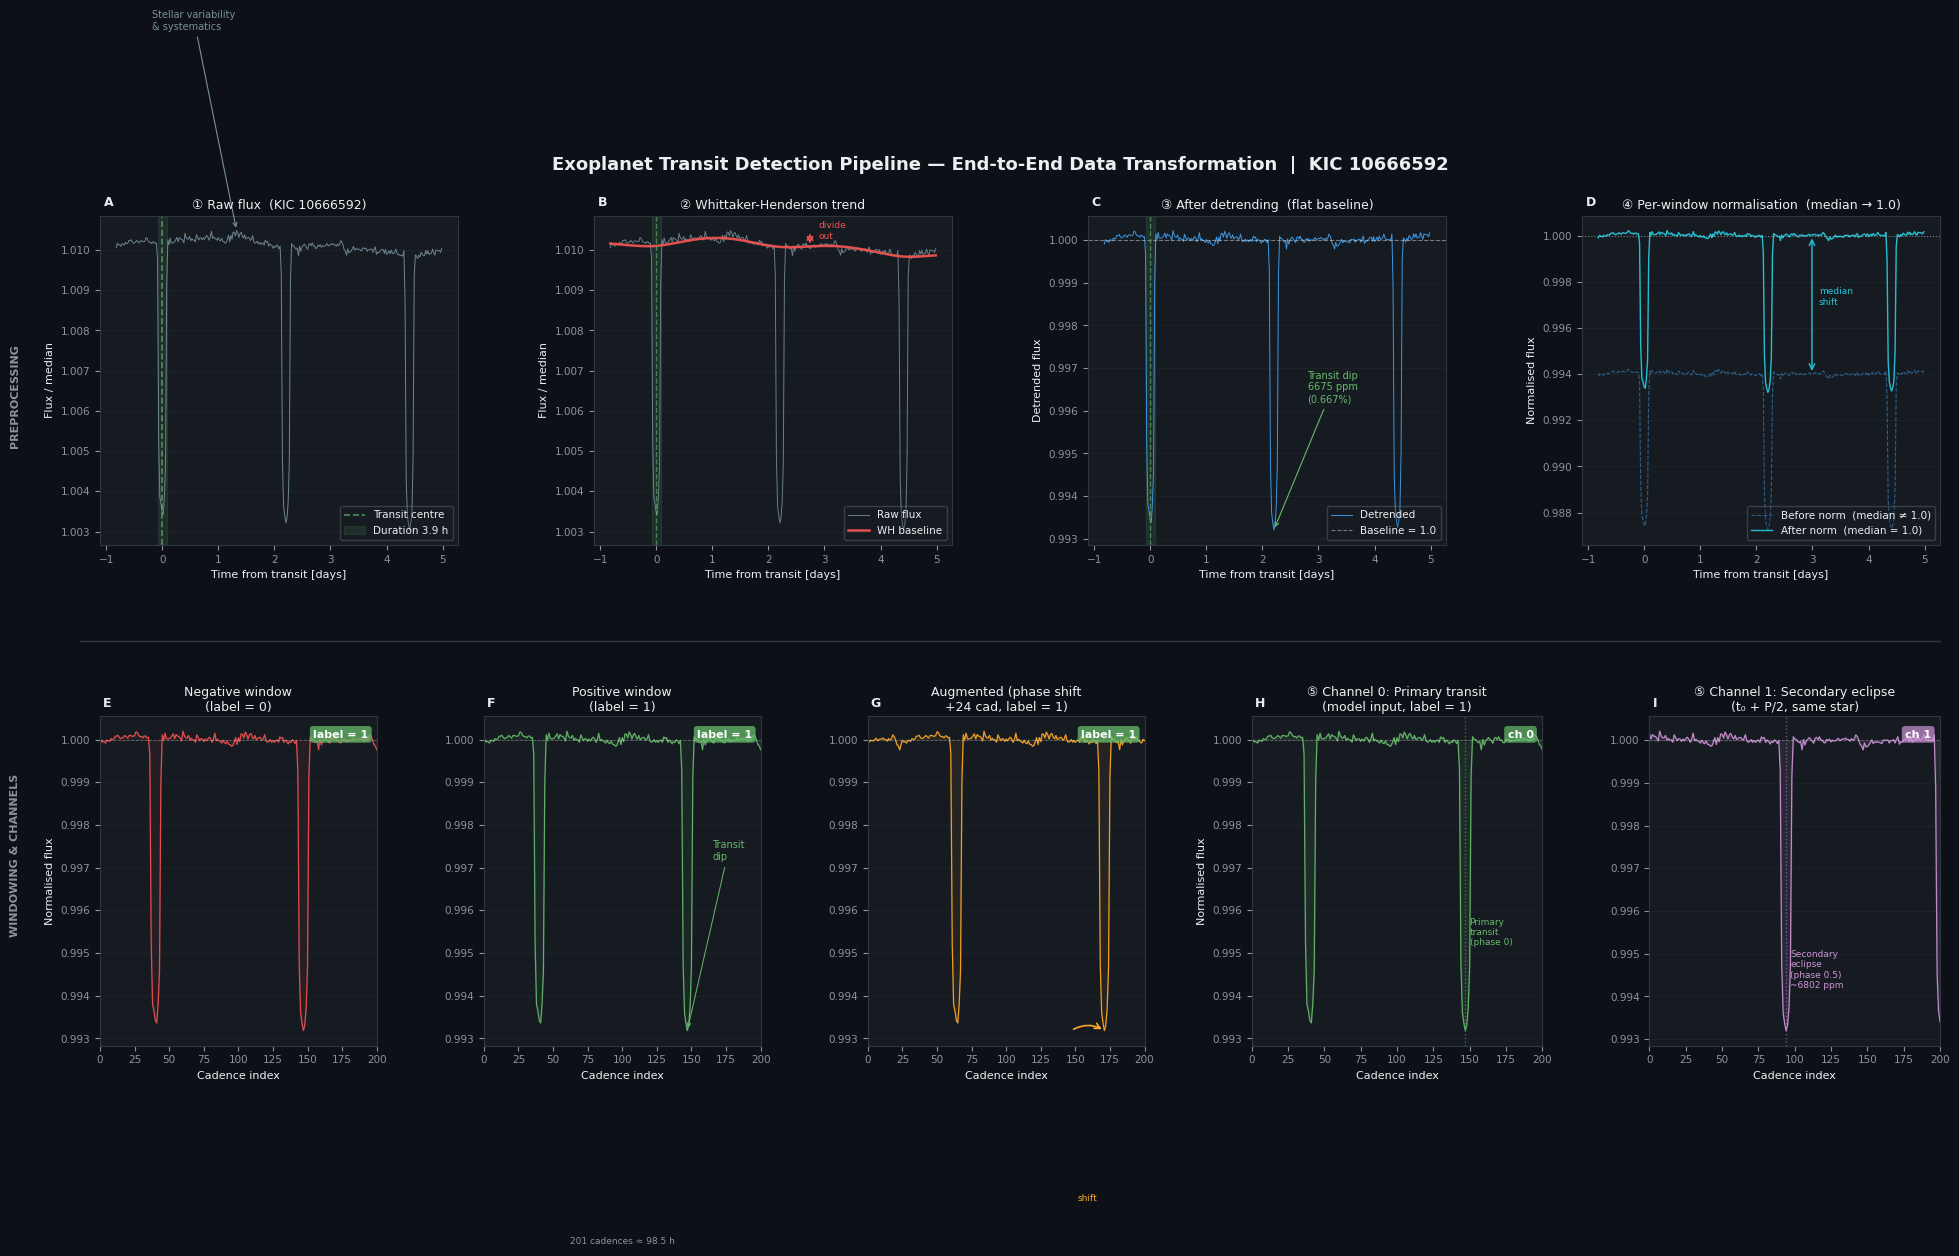

Figure saved → /content/drive/MyDrive/PROJECT_ROOT/figures/08_pipeline_summary.png


In [34]:
# ─── SUMMARY FIGURE: Cell 5 — Master figure assembly ────────────────────────

DARK_BG    = "#0d1117"
PANEL_BG   = "#161b22"
C_RAW      = "#78909C"
C_TREND    = "#EF5350"
C_CLEAN    = "#42A5F5"
C_NORM     = "#26C6DA"
C_POS      = "#66BB6A"
C_NEG      = "#EF5350"
C_AUG      = "#FFA726"
C_SEC      = "#CE93D8"
C_ANNOTATE = "#ECEFF1"
ALPHA_FILL = 0.12

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor":   PANEL_BG,
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  C_ANNOTATE,
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       C_ANNOTATE,
    "grid.color":       "#21262d",
    "grid.linewidth":   0.5,
    "axes.titlesize":   9,
    "axes.labelsize":   8,
    "xtick.labelsize":  7.5,
    "ytick.labelsize":  7.5,
    "legend.fontsize":  7.5,
    "font.family":      "DejaVu Sans",
})

fig = plt.figure(figsize=(20, 10), facecolor=DARK_BG)
fig.subplots_adjust(left=0.05, right=0.97, top=0.91, bottom=0.08,
                    hspace=0.55, wspace=0.38)

outer = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1], hspace=0.52)
gs_A  = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[0], wspace=0.38)
gs_B  = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=outer[1], wspace=0.38,
                                          width_ratios=[1, 1, 1, 1.05, 1.05])

def tag(ax, letter):
    ax.text(0.01, 1.02, letter, transform=ax.transAxes,
            fontsize=9, fontweight="bold", color=C_ANNOTATE, va="bottom")


# ── Panel A — Raw flux zoom ───────────────────────────────────────────────────
ax_raw = fig.add_subplot(gs_A[0])
ax_raw.plot(tz, frz, color=C_RAW, lw=0.7, alpha=0.9, rasterized=True)
ax_raw.axvline(0, color=C_POS, lw=1.2, ls="--", alpha=0.7, label="Transit centre")
ax_raw.axvspan(-dur_days/2, dur_days/2, color=C_POS, alpha=ALPHA_FILL,
               label=f"Duration {dur_days*24:.1f} h")
bump_idx = np.argmax(frz)
ax_raw.annotate("Stellar variability\n& systematics",
                xy=(tz[bump_idx], frz[bump_idx]),
                xytext=(tz[bump_idx] - 1.5, frz[bump_idx] + 0.005),
                fontsize=7, color=C_RAW,
                arrowprops=dict(arrowstyle="->", color=C_RAW, lw=0.8))
ax_raw.set_title(f"① Raw flux  (KIC {VIS_KIC})", pad=5)
ax_raw.set_xlabel("Time from transit [days]")
ax_raw.set_ylabel("Flux / median")
ax_raw.legend(loc="lower right", framealpha=0.2)
ax_raw.grid(True, axis="y")
tag(ax_raw, "A")


# ── Panel B — WH trend overlaid ───────────────────────────────────────────────
ax_trend = fig.add_subplot(gs_A[1])
ax_trend.plot(tz, frz, color=C_RAW,   lw=0.7, alpha=0.85, rasterized=True, label="Raw flux")
ax_trend.plot(tz, fbz, color=C_TREND, lw=1.8, alpha=0.95, label="WH baseline")
ax_trend.axvline(0, color=C_POS, lw=1.0, ls="--", alpha=0.6)
ax_trend.axvspan(-dur_days/2, dur_days/2, color=C_POS, alpha=ALPHA_FILL)
ax_trend.annotate("",
                  xy=(tz[-1]*0.55, fbz[np.argmin(np.abs(tz - tz[-1]*0.55))]),
                  xytext=(tz[-1]*0.55, frz.max()),
                  arrowprops=dict(arrowstyle="<->", color=C_TREND, lw=1.0))
ax_trend.text(tz[-1]*0.55 + 0.15, (fbz.mean() + frz.max()) / 2,
              "divide\nout", fontsize=6.5, color=C_TREND)
ax_trend.set_title("② Whittaker-Henderson trend", pad=5)
ax_trend.set_xlabel("Time from transit [days]")
ax_trend.set_ylabel("Flux / median")
ax_trend.legend(loc="lower right", framealpha=0.2)
ax_trend.grid(True, axis="y")
tag(ax_trend, "B")


# ── Panel C — Detrended flux ──────────────────────────────────────────────────
ax_det = fig.add_subplot(gs_A[2])
ax_det.plot(tz, fcz, color=C_CLEAN, lw=0.7, alpha=0.9, rasterized=True, label="Detrended")
ax_det.axhline(1.0, color="white", lw=0.8, ls="--", alpha=0.4, label="Baseline = 1.0")
ax_det.axvline(0, color=C_POS, lw=1.0, ls="--", alpha=0.6)
ax_det.axvspan(-dur_days/2, dur_days/2, color=C_POS, alpha=ALPHA_FILL)
dip_t   = tz[np.argmin(fcz)]
dip_val = np.nanmin(fcz)
ax_det.annotate(f"Transit dip\n{depth_ppm:.0f} ppm\n({depth_ppm/1e6*100:.3f}%)",
                xy=(dip_t, dip_val),
                xytext=(dip_t + 0.6, dip_val + 0.003),
                fontsize=7, color=C_POS,
                arrowprops=dict(arrowstyle="->", color=C_POS, lw=0.8))
ax_det.set_title("③ After detrending  (flat baseline)", pad=5)
ax_det.set_xlabel("Time from transit [days]")
ax_det.set_ylabel("Detrended flux")
ax_det.legend(loc="lower right", framealpha=0.2)
ax_det.grid(True, axis="y")
tag(ax_det, "C")


# ── Panel D — Normalisation highlight ────────────────────────────────────────
ax_norm = fig.add_subplot(gs_A[3])
before_norm = fcz * 0.994
after_norm  = fcz
ax_norm.plot(tz, before_norm, color=C_CLEAN, lw=0.8, alpha=0.5,
             ls="--", label="Before norm  (median ≠ 1.0)")
ax_norm.plot(tz, after_norm,  color=C_NORM,  lw=1.0, alpha=0.95,
             label="After norm  (median = 1.0)")
ax_norm.axhline(1.0, color="white", lw=0.8, ls=":", alpha=0.4)
x_arrow = tz[-1] * 0.6
y1 = float(np.nanmedian(before_norm))
y2 = 1.0
if abs(y2 - y1) > 1e-6:
    ax_norm.annotate("", xy=(x_arrow, y2), xytext=(x_arrow, y1),
                     arrowprops=dict(arrowstyle="<->", color=C_NORM, lw=1.0))
    ax_norm.text(x_arrow + 0.12, (y1 + y2) / 2,
                 "median\nshift", fontsize=6.5, color=C_NORM)
ax_norm.set_title("④ Per-window normalisation  (median → 1.0)", pad=5)
ax_norm.set_xlabel("Time from transit [days]")
ax_norm.set_ylabel("Normalised flux")
ax_norm.legend(loc="lower right", framealpha=0.2)
ax_norm.grid(True, axis="y")
tag(ax_norm, "D")


# ── Panels E, F, G — Negative / Positive / Augmented windows ─────────────────
window_specs = [
    (w_neg_flux, neg_label, C_NEG, "Negative window\n(label = 0)", "E"),
    (w_pos_flux, pos_label, C_POS, "Positive window\n(label = 1)", "F"),
    (w_aug_flux, pos_label, C_AUG, f"Augmented (phase shift\n+{shift} cad, label = 1)", "G"),
]

for col_idx, (wf, lbl, color, title, letter) in enumerate(window_specs):
    ax_w = fig.add_subplot(gs_B[col_idx])
    ax_w.plot(x_cad, wf, color=color, lw=0.9, alpha=0.92)
    ax_w.axhline(1.0, color="white", lw=0.6, ls="--", alpha=0.3)
    ax_w.fill_between(x_cad, wf, 1.0, color=color, alpha=0.07)

    badge_color = C_POS if lbl == 1 else C_NEG
    ax_w.text(0.97, 0.96, f"label = {lbl}",
              transform=ax_w.transAxes, ha="right", va="top",
              fontsize=8, fontweight="bold", color="white",
              bbox=dict(boxstyle="round,pad=0.3", facecolor=badge_color, alpha=0.75, lw=0))

    if lbl == 1 and col_idx == 1:
        dip_idx = int(np.argmin(wf))
        ax_w.annotate("Transit\ndip",
                      xy=(dip_idx, wf[dip_idx]),
                      xytext=(dip_idx + 18, wf[dip_idx] + 0.004),
                      fontsize=7, color=color,
                      arrowprops=dict(arrowstyle="->", color=color, lw=0.7))
        ax_w.annotate("",
                      xy=(0, wf.min() - 0.003),
                      xytext=(W - 1, wf.min() - 0.003),
                      arrowprops=dict(arrowstyle="<->", color="#8b949e", lw=0.7))
        ax_w.text(W // 2, wf.min() - 0.005,
                  f"201 cadences ≈ {WINDOW_DAYS*24:.1f} h",
                  ha="center", fontsize=6.5, color="#8b949e")

    if col_idx == 2:
        orig_dip = int(np.argmin(w_pos_flux))
        aug_dip  = int(np.argmin(wf))
        ax_w.annotate("",
                      xy=(aug_dip, wf.min()),
                      xytext=(orig_dip, wf.min()),
                      arrowprops=dict(arrowstyle="->", color=C_AUG, lw=1.2,
                                      connectionstyle="arc3,rad=-0.3"))
        ax_w.text((orig_dip + aug_dip) // 2, wf.min() - 0.004,
                  "shift", ha="center", fontsize=6.5, color=C_AUG)

    ax_w.set_title(title, pad=4)
    ax_w.set_xlabel("Cadence index")
    ax_w.set_ylabel("Normalised flux" if col_idx == 0 else "")
    ax_w.set_xlim(0, W - 1)
    ax_w.grid(True, axis="y")
    tag(ax_w, letter)


# ── Panel H — Channel 0: Primary transit ─────────────────────────────────────
ax_ch0 = fig.add_subplot(gs_B[3])
ax_ch0.plot(x_cad, w_pos_flux, color=C_POS, lw=0.9, alpha=0.92)
ax_ch0.fill_between(x_cad, w_pos_flux, 1.0, color=C_POS, alpha=0.1)
ax_ch0.axhline(1.0, color="white", lw=0.6, ls="--", alpha=0.3)
dip_idx = int(np.argmin(w_pos_flux))
ax_ch0.axvline(dip_idx, color=C_POS, lw=1.0, ls=":", alpha=0.5)
ax_ch0.text(dip_idx + 3, float(w_pos_flux.min()) + 0.002,
            "Primary\ntransit\n(phase 0)", fontsize=6.5, color=C_POS)
ax_ch0.text(0.97, 0.96, "ch 0", transform=ax_ch0.transAxes,
            ha="right", va="top", fontsize=8, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.3", facecolor=C_POS, alpha=0.7, lw=0))
ax_ch0.set_title("⑤ Channel 0: Primary transit\n(model input, label = 1)", pad=4)
ax_ch0.set_xlabel("Cadence index")
ax_ch0.set_ylabel("Normalised flux")
ax_ch0.set_xlim(0, W - 1)
ax_ch0.grid(True, axis="y")
tag(ax_ch0, "H")


# ── Panel I — Channel 1: Secondary eclipse ───────────────────────────────────
ax_ch1 = fig.add_subplot(gs_B[4])
ax_ch1.plot(x_cad, sec_channel, color=C_SEC, lw=0.9, alpha=0.92)
ax_ch1.fill_between(x_cad, sec_channel, 1.0, color=C_SEC, alpha=0.1)
ax_ch1.axhline(1.0, color="white", lw=0.6, ls="--", alpha=0.3)

sec_dip_depth     = 1.0 - float(np.nanmin(sec_channel))
sec_dip_idx       = int(np.argmin(sec_channel))
is_real_secondary = sec_dip_depth > 50e-6

if is_real_secondary:
    ax_ch1.axvline(sec_dip_idx, color=C_SEC, lw=1.0, ls=":", alpha=0.5)
    ax_ch1.text(sec_dip_idx + 3, float(sec_channel.min()) + 0.001,
                f"Secondary\neclipse\n(phase 0.5)\n~{sec_dip_depth*1e6:.0f} ppm",
                fontsize=6.5, color=C_SEC)
else:
    ax_ch1.text(0.5, 0.5,
                "Secondary eclipse\noutside LC bounds\n→ filled with 1.0",
                transform=ax_ch1.transAxes, ha="center", va="center",
                fontsize=7.5, color=C_SEC, style="italic",
                bbox=dict(boxstyle="round,pad=0.4", facecolor=PANEL_BG, alpha=0.8, lw=0))

ax_ch1.text(0.97, 0.96, "ch 1", transform=ax_ch1.transAxes,
            ha="right", va="top", fontsize=8, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.3", facecolor=C_SEC, alpha=0.7, lw=0))
ax_ch1.set_title("⑤ Channel 1: Secondary eclipse\n(t₀ + P/2, same star)", pad=4)
ax_ch1.set_xlabel("Cadence index")
ax_ch1.set_ylabel("")
ax_ch1.set_xlim(0, W - 1)
ax_ch1.grid(True, axis="y")
tag(ax_ch1, "I")


# ── Super-title & decorations ─────────────────────────────────────────────────
fig.suptitle(
    f"Exoplanet Transit Detection Pipeline — End-to-End Data Transformation  |  KIC {VIS_KIC}",
    fontsize=13, fontweight="bold", color=C_ANNOTATE, y=0.97,
)
fig.text(0.005, 0.73, "PREPROCESSING", fontsize=8, fontweight="bold",
         color="#8b949e", rotation=90, va="center")
fig.text(0.005, 0.27, "WINDOWING & CHANNELS", fontsize=8, fontweight="bold",
         color="#8b949e", rotation=90, va="center")
sep_line = plt.Line2D([0.04, 0.97], [0.485, 0.485],
                      transform=fig.transFigure, color="#30363d", lw=1.0)
fig.add_artist(sep_line)

# ── Save ──────────────────────────────────────────────────────────────────────
out_path = FIGURES_DIR / "08_pipeline_summary.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print(f"Figure saved → {out_path}")